# MMJL Capture and Notebook-State Regression Test

**1. Markdown cell — test purpose and execution order**

This notebook tests:

1. repository-root discovery from anywhere inside the repository
2. `src/` import setup
3. MMJL utility imports
4. Jupyter magic registration
5. literal Markdown and HTML logging
6. `%%jupy_capture`
7. the `%%jupy_tee` alias
8. failed notebook-state execution in visible order:
   `A -> B -> C`
9. successful recovery by moving backward:
   `B -> A`
10. stdout, exception, rich-display, and Matplotlib capture
11. `%jupy_file`
12. manifest inspection and validation
13. Markdown and HTML timeline generation
14. the Python analogs of `tree`, `wc -l`, and `cat`

The notebook-state dependency graph is:

```text
C creates numbers
B consumes numbers and creates squared_numbers
A consumes numbers and squared_numbers, computes a mean, and plots
```

The cells are displayed as:

```text
A
B
C
B again
A again
```

Therefore the first A and B should fail, C should succeed, and the
subsequent B and A should succeed.

---

**Looking further**:

Here is the complete notebook sequence. The intended execution order is the notebook's ordinary top-to-bottom order, with the exception of the A → B → C → B → A example

---

**Let's go!!!**<br/><br/>

In [1]:
## 2. Code cell 01 — locate the repository root and configure `sys.path`
import importlib
import os
import sys
import pathlib

starting_dir = pathlib.Path.cwd().resolve()
repo_root = None
src_path = None
package_path = None

for candidate_path in [starting_dir, *starting_dir.parents]:
    package_path = (
        candidate_path
        / "src"
        / "multimodal_jupy_logger"
    )

    if package_path.is_dir():
        repo_root = candidate_path
        break
    ##endof:  if package_path.is_dir()
##endof:  for candidate_path in [...]

if repo_root is None:
    raise RuntimeError(
        "Could not find a repository root containing "
        "src/multimodal_jupy_logger."
    )
##endof:  if repo_root is None

src_path = repo_root / "src"

os.chdir(repo_root)

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
##endof:  if str(src_path) not in sys.path

importlib.invalidate_caches()

print("starting_dir:", starting_dir)
print("repo_root:", repo_root)
print("src_path:", src_path)
print("current working directory:", pathlib.Path.cwd())
print("Python executable:", sys.executable)

starting_dir: D:\David\my_repos_dwb\multimodal-jupy-logger\examples
repo_root: D:\David\my_repos_dwb\multimodal-jupy-logger
src_path: D:\David\my_repos_dwb\multimodal-jupy-logger\src
current working directory: D:\David\my_repos_dwb\multimodal-jupy-logger
Python executable: D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Scripts\python.exe


<details>
<summary>Click to see an example output</summary>

<pre>
starting_dir: D:\David\my_repos_dwb\multimodal-jupy-logger\examples
repo_root: D:\David\my_repos_dwb\multimodal-jupy-logger
src_path: D:\David\my_repos_dwb\multimodal-jupy-logger\src
current working directory: D:\David\my_repos_dwb\multimodal-jupy-logger
Python executable: D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Scripts\python.exe
</pre>

</details>

In [2]:
## 3. Code cell 02 — import MMJL and the path-display utilities
from multimodal_jupy_logger import (
    MultimodalJupyLogger,
    jupy_logger_register,
    register_jupy_logger,
)

from multimodal_jupy_logger.utils import (
    count_lines,
    path_display,
    print_file,
    tree,
)

from multimodal_jupy_logger.utils import path_display as dpypd

print("MMJL imports succeeded.")
print("path_display module:", dpypd)

MMJL imports succeeded.
path_display module: <module 'multimodal_jupy_logger.utils.path_display' from 'D:\\David\\my_repos_dwb\\multimodal-jupy-logger\\src\\multimodal_jupy_logger\\utils\\path_display.py'>


<details>
<summary>Click to see an example output</summary>

<pre>
MMJL imports succeeded.
path_display module: &lt;module 'multimodal_jupy_logger.utils.path_display' from 'D:\\David\\my_repos_dwb\\multimodal-jupy-logger\\src\\multimodal_jupy_logger\\utils\\path_display.py'&gt;
</pre>

</details>

## Manifest and Artifact Lookup Helpers

This notebook is a development lab, so this cell gives us stable ways to
inspect MMJL output after a kernel restart. The manifest and artifacts live
on disk, even when Python state is gone.

Use examples:

```python
show_manifest()
show_manifest(label_contains="abc-second-pass-a")
show_artifact(23)
```


In [3]:
## Code cell 03

## Development helper cell -- inspect manifest rows and artifacts.
## This cell is notebook-local; it is not part of the MMJL public API.

import csv
import json
import mimetypes
import pathlib

from typing import Any

from IPython.display import HTML, Image, Markdown, display


ManifestRow = dict[str, Any]


def find_repo_root(
      starting_dir: pathlib.Path | str | None = None,
    ) -> pathlib.Path:
    '''
    Find the repository root from the current notebook location.
    '''

    starting_path = (
        pathlib.Path.cwd()
        if starting_dir is None
        else pathlib.Path(starting_dir)
    )
    starting_path = starting_path.resolve()

    for candidate_path in [starting_path, *starting_path.parents]:
        package_path = (
            candidate_path
            / "src"
            / "multimodal_jupy_logger"
        )

        if package_path.is_dir():
            return candidate_path
        ##endof:  if package_path.is_dir()
    ##endof:  for candidate_path in [...]

    raise RuntimeError("Could not find MMJL repository root.")
##endof:  find_repo_root


def read_mmjl_manifest(
      log_root: pathlib.Path | str | None = None,
    ) -> tuple[pathlib.Path, list[ManifestRow]]:
    '''
    Read the MMJL manifest as TSV rows.
    '''

    if log_root is None:
        local_repo_root = find_repo_root()
        log_root = local_repo_root / "jupy_log"
    ##endof:  if log_root is None

    log_root = pathlib.Path(log_root)
    manifest_path = log_root / "manifest.tsv"

    with manifest_path.open("r", encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle, delimiter="\t"))
    ##endof:  with manifest_path.open(...)

    return manifest_path, rows
##endof:  read_mmjl_manifest


def _row_int(
      row: ManifestRow,
      key: str,
      default: int = -1,
    ) -> int:
    '''
    Read an integer-ish manifest field for sorting/filtering.
    '''

    value = row.get(key, "")

    try:
        return int(value)
    except (TypeError, ValueError):
        return default
    ##endof:  try/except (TypeError, ValueError)
##endof:  _row_int


def show_manifest(
      limit: int = 20,
      log_root: pathlib.Path | str | None = None,
      label_contains: str | None = None,
    ) -> None:
    '''
    Print a compact view of recent manifest rows.
    '''

    manifest_path, rows = read_mmjl_manifest(log_root=log_root)

    if label_contains is not None:
        rows = [
            row for row in rows
            if label_contains.lower() in row.get("label", "").lower()
        ]
    ##endof:  if label_contains is not None

    rows = sorted(
        rows,
        key=lambda row: _row_int(row, "artifact_sequence"),
    )

    print(f"manifest: {manifest_path}")
    print(f"rows: {len(rows)}")
    print()

    for row in rows[-limit:]:
        print(
            row.get("artifact_sequence", ""),
            row.get("capture_sequence", ""),
            row.get("role", ""),
            row.get("mime", ""),
            row.get("label", ""),
            row.get("path", ""),
            sep=" | ",
        )
    ##endof:  for row in rows[-limit:]
##endof:  show_manifest


def get_artifact_row(
      artifact_sequence: int,
      log_root: pathlib.Path | str | None = None,
    ) -> tuple[pathlib.Path, ManifestRow]:
    '''
    Return the manifest row for one artifact sequence.
    '''

    manifest_path, rows = read_mmjl_manifest(log_root=log_root)
    target = int(artifact_sequence)

    for row in rows:
        if _row_int(row, "artifact_sequence") == target:
            return manifest_path, row
        ##endof:  if _row_int(row, "artifact_sequence") == target
    ##endof:  for row in rows

    raise KeyError(f"No artifact_sequence found: {artifact_sequence}")
##endof:  get_artifact_row


def resolve_artifact_path(
      manifest_path: pathlib.Path | str,
      row: ManifestRow,
    ) -> pathlib.Path:
    '''
    Resolve a manifest artifact path against the manifest directory.
    '''

    manifest_dir = pathlib.Path(manifest_path).parent
    artifact_path = pathlib.Path(row.get("path", ""))

    if not artifact_path.is_absolute():
        artifact_path = manifest_dir / artifact_path
    ##endof:  if not artifact_path.is_absolute()

    return artifact_path.resolve()
##endof:  resolve_artifact_path


def show_artifact(
      artifact_sequence: int,
      log_root: pathlib.Path | str | None = None,
    ) -> ManifestRow:
    '''
    Display one logged artifact by its monotonic artifact sequence.
    '''

    manifest_path, row = get_artifact_row(
        artifact_sequence,
        log_root=log_root,
    )
    artifact_path = resolve_artifact_path(manifest_path, row)
    guessed_mime = mimetypes.guess_type(artifact_path)[0]
    mime = row.get("mime", "") or guessed_mime or ""

    print(f"artifact_sequence: {row.get('artifact_sequence')}")
    print(f"capture_sequence: {row.get('capture_sequence')}")
    print(f"role: {row.get('role')}")
    print(f"label: {row.get('label')}")
    print(f"mime: {mime}")
    print(f"path: {artifact_path}")
    print(f"exists: {artifact_path.exists()}")
    print()

    if not artifact_path.exists():
        return row
    ##endof:  if not artifact_path.exists()

    if mime == "image/png":
        display(Image(filename=str(artifact_path)))
    elif mime == "image/svg+xml":
        display(HTML(artifact_path.read_text(encoding="utf-8")))
    elif mime in ["text/markdown", "text/x-markdown"]:
        display(Markdown(artifact_path.read_text(encoding="utf-8")))
    elif mime == "text/html":
        display(HTML(artifact_path.read_text(encoding="utf-8")))
    elif mime == "application/json":
        print(json.dumps(
            json.loads(artifact_path.read_text(encoding="utf-8")),
            indent=2,
        ))
    elif mime.startswith("text/"):
        print(artifact_path.read_text(
            encoding="utf-8",
            errors="replace",
        ))
    else:
        print("No display rule for this MIME type.")
    ##endof:  if/elif MIME display

    return row
##endof:  show_artifact


def display_banner(my_char: str='-', my_len: int=65) -> None: 
    print(my_len*my_char)
##endof:  display_banner(...)

<details>
<summary>There is no output.</summary>

It was good of you to check. See, no monospace stuff.

</details>

In [4]:
## 4. Code cell 04 — prove both utility import styles work

print("Directly imported function:")
print("  tree:", tree)

print("\nModule-namespace functions:")
print("  dpypd.tree:", dpypd.tree)
print("  dpypd.count_lines:", dpypd.count_lines)
print("  dpypd.print_file:", dpypd.print_file)

print("\nDirect and module attributes refer to the same functions:")
print("  tree is dpypd.tree:", tree is dpypd.tree)
print(
    "  count_lines is dpypd.count_lines:",
    count_lines is dpypd.count_lines,
)
print(
    "  print_file is dpypd.print_file:",
    print_file is dpypd.print_file,
)

Directly imported function:
  tree: <function tree at 0x000001AC1ED0EF20>

Module-namespace functions:
  dpypd.tree: <function tree at 0x000001AC1ED0EF20>
  dpypd.count_lines: <function count_lines at 0x000001AC1ED0EFC0>
  dpypd.print_file: <function print_file at 0x000001AC1ED0F060>

Direct and module attributes refer to the same functions:
  tree is dpypd.tree: True
  count_lines is dpypd.count_lines: True
  print_file is dpypd.print_file: True


<details>
<summary>Click to see an example output (remember to escape)</summary>

<pre>
Directly imported function:
  tree: &lt;function tree at 0x000001AC1ED0EF20&gt;

Module-namespace functions:
  dpypd.tree: &lt;function tree at 0x000001AC1ED0EF20&gt;
  dpypd.count_lines: &lt;function count_lines at 0x000001AC1ED0EFC0&gt;
  dpypd.print_file: &lt;function print_file at 0x000001AC1ED0F060&gt;

Direct and module attributes refer to the same functions:
  tree is dpypd.tree: True
  count_lines is dpypd.count_lines: True
  print_file is dpypd.print_file: True
</pre>

</details>

In [5]:
## 5. Code cell 05 — show the relevant repository tree

dpypd.tree(
    this_dir=repo_root,
    dirs_to_exclude=[
        ".git",
        "__pycache__",
        ".venv",
        ".venv_test_mmjl",
        ".ipynb_checkpoints",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

+ D:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + docs/
        + dev_notes/
            + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
            + dev_notes_on_-_jupy_pdf_utils_py.md
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
            + template_count_lines.py
            + template_print_file.py
            + test_setup_and_start.md
    + examples/
        + mmjl_capture_and_state_smoke_test.ipynb
        + mmjl_capture_and_state_smoke_test_1781817012.ipynb
        + mmjl_capture_debugging_lab.ipynb
        + mmjl_capture_debugging_pre.ipynb
        + mmjl_first_smoke_test.ipynb
        + mmjl_quickstart_demo.ipynb
    + LICENSE
    + README.md
    + repr_win_laptop_init__requ

<details>
<summary>Click to see an example output</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + docs/
        + dev_notes/
            + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
            + dev_notes_on_-_jupy_pdf_utils_py.md
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
            + template_count_lines.py
            + template_print_file.py
            + test_setup_and_start.md
    + examples/
        + mmjl_capture_and_state_smoke_test.ipynb
        + mmjl_capture_and_state_smoke_test_1781817012.ipynb
        + mmjl_capture_debugging_lab.ipynb
        + mmjl_capture_debugging_pre.ipynb
        + mmjl_first_smoke_test.ipynb
        + mmjl_quickstart_demo.ipynb
    + LICENSE
    + README.md
    + repr_win_laptop_init__requirements.txt
    + reproducibility_win_init__requirements.txt
    + requirements-ml.txt
    + requirements.txt
    + src/
        + multimodal_jupy_logger/
            + __init__.py
            + jupy_pdf_utils.py
            + logger.py
            + magics.py
            + metadata.py
            + mmjl_cli.py
            + utils/
                + __init__.py
                + path_display.py
</pre>

</details>

For:  **6**

Run this after restarting the kernel and loading the updated files. 
(If you've run the last cells, this is almost certainly done.)

```python
register_jupy_logger()
```

Expected registration text includes:

```text
%%jupy_log
%%jupy_capture
%%jupy_tee
```

In [6]:
## 6. Code cell 06 — register the magics

register_jupy_logger()

display_banner()
display_banner("=")
print("THAT'S WHAT YOU'LL WANT TO BE LOOKING FOR, RIGHT THERE!")
display_banner("=")
print()
display_banner()
print("Important to see that this created some directories for us.")
display_banner()
dpypd.tree(
    this_dir=repo_root,
    dirs_to_exclude=[
        ".git",
        "__pycache__",
        ".venv",
        ".venv_test_mmjl",
        ".ipynb_checkpoints",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

[DONE] Registered: %jupy_save, %jupy_file, %%jupy_log, %%jupy_capture, %%jupy_tee, %jupy_markdown, %jupy_html, %jupy_inspect, %jupy_validate
-----------------------------------------------------------------
THAT'S WHAT YOU'LL WANT TO BE LOOKING FOR, RIGHT THERE!

-----------------------------------------------------------------
Important to see that this created some directories for us.
-----------------------------------------------------------------
+ D:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + docs/
        + dev_notes/
            + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
            + dev_notes_on_-_jupy_pdf_utils_py.md
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
       

<details>
<summary>Click to see an example output</summary>

<pre>
[DONE] Registered: %jupy_save, %jupy_file, %%jupy_log, %%jupy_capture, %%jupy_tee, %jupy_markdown, %jupy_html, %jupy_inspect, %jupy_validate
-----------------------------------------------------------------
=================================================================
THAT'S WHAT YOU'LL WANT TO BE LOOKING FOR, RIGHT THERE!
=================================================================

-----------------------------------------------------------------
Important to see that this created some directories for us.
-----------------------------------------------------------------
+ D:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + docs/
        + dev_notes/
            + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
            + dev_notes_on_-_jupy_pdf_utils_py.md
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
            + template_count_lines.py
            + template_print_file.py
            + test_setup_and_start.md
    + examples/
        + mmjl_capture_and_state_smoke_test.ipynb
        + mmjl_capture_and_state_smoke_test_1781817012.ipynb
        + mmjl_capture_debugging_lab.ipynb
        + mmjl_capture_debugging_pre.ipynb
        + mmjl_first_smoke_test.ipynb
        + mmjl_quickstart_demo.ipynb
    + jupy_log/
        + artifacts/
        + manifest.tsv
        + staging/
        + timelines/
    + LICENSE
    + README.md
    + repr_win_laptop_init__requirements.txt
    + reproducibility_win_init__requirements.txt
    + requirements-ml.txt
    + requirements.txt
    + src/
        + multimodal_jupy_logger/
            + __init__.py
            + jupy_pdf_utils.py
            + logger.py
            + magics.py
            + metadata.py
            + mmjl_cli.py
            + utils/
                + __init__.py
                + path_display.py
</pre>

</details>

<hr/>

***Info***

`REPO_ROOT/jupy_log` created after `Code cell 06`. Trust me. Actually, you don't have to take my word for it (Lavar Burton,) look at the output from the cell above.

<hr/>

In [7]:
## 7. Code cell 07 — verify that the magics exist

ipython_shell = get_ipython()

magic_names = [
    "jupy_save",
    "jupy_file",
    "jupy_log",
    "jupy_capture",
    "jupy_tee",
    "jupy_markdown",
    "jupy_html",
    "jupy_inspect",
    "jupy_validate",
]

for magic_name in magic_names:
    line_magic = ipython_shell.find_line_magic(magic_name)
    cell_magic = ipython_shell.find_cell_magic(magic_name)

    print(
        f"{magic_name:16s}",
        f"line={line_magic is not None}",
        f"cell={cell_magic is not None}",
    )
##endof:  for magic_name in magic_names

jupy_save        line=True cell=False
jupy_file        line=True cell=False
jupy_log         line=False cell=True
jupy_capture     line=False cell=True
jupy_tee         line=False cell=True
jupy_markdown    line=True cell=False
jupy_html        line=True cell=False
jupy_inspect     line=True cell=False
jupy_validate    line=True cell=False


<details>
<summary>Click to see an example output</summary>

<pre>
jupy_save        line=True cell=False
jupy_file        line=True cell=False
jupy_log         line=False cell=True
jupy_capture     line=False cell=True
jupy_tee         line=False cell=True
jupy_markdown    line=True cell=False
jupy_html        line=True cell=False
jupy_inspect     line=True cell=False
jupy_validate    line=True cell=False
</pre>

</details>

**8. Markdown cell — notebook-native hidden-text control**

This cell tests Jupyter’s own Markdown rendering independently of MMJL.

```markdown
<strong>Notebook-native `<details>` control</strong>

<details>
<summary>Click the arrow to reveal the notebook-native text</summary>

This text lives directly in a Jupyter Markdown cell.

If clicking the arrow reveals this paragraph, the notebook frontend is
rendering the HTML element correctly.

</details>
```

---

_DWB Note: I think we want to test the following:_

<strong>Notebook-native `<details>` control</strong>

<details>
<summary>Click the arrow to reveal the notebook-native text</summary>

This text lives directly in a Jupyter Markdown cell.

If clicking the arrow reveals this paragraph, the notebook frontend is
rendering the HTML element correctly.

</details>

<br/><hr/>

For **9** (`Code cell 08 — log the original Markdown regression case`)

This preserves the original test: raw `<details>` HTML stored with the
`text/markdown` MIME type.

In [8]:
%%jupy_log --label details-summary-markdown-regression --mime text/markdown
<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

<!-- ## 9. Code cell 08 — log the original Markdown regression case -->
<!--   If I had left the python comment without the HTML comment,   -->
<!-- + it would have rendered as an `h2`. But you might only see    -->
<!-- + this in the dpypd.print_file version.                        -->

<br/>HTML comments above.<br/>Hopefully you can see the utility of jupy_log
as a note-taking device.

[DONE] Logged text: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md


<details>
<summary>Click to see an example output</summary>

<pre>
[DONE] Logged text: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
</pre>

</details>

For **10** (`Code cell 09 — log an HTML control version`)

This distinguishes a general `<details>` failure from a Markdown-MIME
rendering-policy failure.

With the current timeline builder, the expected distinction is:

* `text/html`: should render as a collapsible block in the HTML timeline
* `text/markdown`: currently may appear as escaped/fenced source

That would identify a timeline-rendering issue, not a capture failure.

In [9]:
%%jupy_log --label details-summary-html-control --mime text/html
<details>
<summary>Click the arrow to reveal logged HTML text</summary>

<p>
This content was logged as <code>text/html</code>. It should be inserted
as HTML in the generated HTML timeline.
</p>

</details>

## 10. Code cell 09 — log an HTML control version

<!--   I can leave the python comment above as-is, since this is -->
<!-- + HTML and not markdown. But you might only see this in the -->
<!-- + dpypd.print_file version.                                 -->

<br/>HTML comments above.<br/>Hopefully you can see the utility of jupy_log
as a note-taking device.

[DONE] Logged text: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html


<details>
<summary>Click to see an example output</summary>

<pre>
[DONE] Logged text: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
</pre>

</details>

In [10]:
# Code cell 10

dpypd.tree(
    this_dir=repo_root,
    dirs_to_exclude=[
        ".git",
        "__pycache__",
        ".venv",
        ".venv_test_mmjl",
        ".ipynb_checkpoints",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

+ D:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + docs/
        + dev_notes/
            + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
            + dev_notes_on_-_jupy_pdf_utils_py.md
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
            + template_count_lines.py
            + template_print_file.py
            + test_setup_and_start.md
    + examples/
        + mmjl_capture_and_state_smoke_test.ipynb
        + mmjl_capture_and_state_smoke_test_1781817012.ipynb
        + mmjl_capture_debugging_lab.ipynb
        + mmjl_capture_debugging_pre.ipynb
        + mmjl_first_smoke_test.ipynb
        + mmjl_quickstart_demo.ipynb
    + jupy_log/
        + artifacts/
            + 000001_1782

<details>
<summary>Click to see an example output</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger
    + .gitattributes
    + .gitignore
    + docs/
        + dev_notes/
            + complete_pre_jupyter_lab_powershell_io_2026-06-14T152800-0400.log
            + dev_notes_on_-_jupy_pdf_utils_py.md
            + first_mmjl_smoke_test_2026-06-14.md
            + git_changing_executed_filename_learning_2026-06-17.md
            + jupyter_cell_magic_first_line_learning_2026-06-17.md
            + mmjl_capture_and_state_testing_-_PLAN_2026-06-16.md
            + template_both_better.py
            + template_count_lines.py
            + template_print_file.py
            + test_setup_and_start.md
    + examples/
        + mmjl_capture_and_state_smoke_test.ipynb
        + mmjl_capture_and_state_smoke_test_1781817012.ipynb
        + mmjl_capture_debugging_lab.ipynb
        + mmjl_capture_debugging_pre.ipynb
        + mmjl_first_smoke_test.ipynb
        + mmjl_quickstart_demo.ipynb
    + jupy_log/
        + artifacts/
            + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
            + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + manifest.tsv
        + staging/
        + timelines/
    + LICENSE
    + README.md
    + repr_win_laptop_init__requirements.txt
    + reproducibility_win_init__requirements.txt
    + requirements-ml.txt
    + requirements.txt
    + src/
        + multimodal_jupy_logger/
            + __init__.py
            + jupy_pdf_utils.py
            + logger.py
            + magics.py
            + metadata.py
            + mmjl_cli.py
            + utils/
                + __init__.py
                + path_display.py
</pre>

</details>

In [11]:
## Code cell 11

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
    + manifest.tsv
    + staging/
    + timelines/


<details>
<summary>Click to see an example output</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
    + manifest.tsv
    + staging/
    + timelines/
</pre>

</details>

In [12]:
## Code cell 12, better manifest display

display_banner()
show_manifest(limit=20)
display_banner()
print()
print("That's the previous tries and the start of this one...")
print("Unless, as is the case now, this is a different machine,")
print("so there are only the two new entries.")

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 2

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
-----------------------------------------------------------------

That's the previous tries and the start of this one...
Unless, as is the case now, this is a different machine,
so there are only the two new entries.


<details>
<summary>Click to see an example output</summary>

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 2

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
-----------------------------------------------------------------

That's the previous tries and the start of this one...
Unless, as is the case now, this is a different machine,
so there are only the two new entries.
</pre>

</details>

<br/><hr/>
<div>
<span style="font-size:150%; font-face:bold">MUST 
    CHANGE (or at least check) <code>show_artifact</code> NUMBERS 
    BELOW!</span>
</div>
<br/>
<div>
<span style="font-size:200%; font-face:bold">ABSOLUTELY MUST
    &nbsp;</span><span style="font-size:150%; font-face:bold">MANUALLY
    PUT IN THE FIRST PART OF THE FILENAMES, BELOW, FROM THE FIRST
    NUMBER THROUGH THE LAST UNDERSCORE!</span>
</div>
<div>(The <code>path_second_part</code> variables,
    of which there are two.)</div>

In [13]:
##  Code cell 13 — ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(1)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(2)
display_banner()
print(); print()
display_banner("#", 72)

print();print();print()
display_banner("#", 68)
print("### ONLY FOR THIS REGRESSION TEST, WE dpypd.print_file TWO FILES ###")
display_banner("#", 68)
print();print();print()

##  Refer to src = "bballdave025/multimodal_jupy_logger/" + 
##+   "/mmjl_capture_and_state_smoke_test_1781817012.ipynb"
##+ for how to use this compact code.
hashes="#"*63; dashes="-"*59; equalses="="*59; print_start="___Fil" + \
"e contents for___\n   'jupy_log/"; count_start="___File line coun" + \
"t for___\n   'jupy_log/"; full_stem_path=f"{repo_root}/jupy_log/";
either_end=f"'___\n{dashes}\n";     print(f"{hashes}\n{dashes}\n");

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
path_second_part="";path_third_part="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000001_1782759815228_2026-06-29T150335228-0400_";
path_third_part ="details-summary-markdown-regression.md";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
the_right_end=contd_bigger_end;
#d.2  #the_right_end=ended_bigger_end;
print(the_right_end)

the_right_start=the_right_end="!";dpath_post_jupy_log="";art_str="";
path_second_part="";path_third_part="";
the_right_start = print_start;
#a.2  #the_right_start = count_start;
art_str="artifacts/";
short_pth="";
dpath_post_jupy_log=f"{art_str}{short_pth}";
path_second_part="000002_1782759848405_2026-06-29T150408405-0400_";
path_third_part ="details-summary-html-control.html";
dpath_post_jupy_log+=f"\n{path_second_part}\n{path_third_part}";
path_pass=(  f"{full_stem_path}{art_str}{short_pth}{path_second_part}"
f"{path_third_part}");print((f"{the_right_start}{dpath_post_jupy_log}"
f"{either_end}") ); dpypd.print_file(path_pass) \
if the_right_start == print_start  else dpypd.count_lines(path_pass); 
contd_bigger_end=f"{dashes}\n{equalses}\n\n{equalses}\n{dashes}\n";
ended_bigger_end=f"{dashes}\n\n\n{hashes}";
#d.1  #the_right_end=contd_bigger_end;
the_right_end=ended_bigger_end;
print(the_right_end)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000001
capture_sequence: 
role: literal
label: details-summary-markdown-regression
mime: text/markdown
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
exists: True



<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

<!-- ## 9. Code cell 08 — log the original Markdown regression case -->
<!--   If I had left the python comment without the HTML comment,   -->
<!-- + it would have rendered as an `h2`. But you might only see    -->
<!-- + this in the dpypd.print_file version.                        -->

<br/>HTML comments above.<br/>Hopefully you can see the utility of jupy_log
as a note-taking device.


-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000002
capture_sequence: 
role: literal
label: details-summary-html-control
mime: text/html
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
exists: True



-----------------------------------------------------------------


########################################################################



####################################################################
### ONLY FOR THIS REGRESSION TEST, WE dpypd.print_file TWO FILES ###
####################################################################



###############################################################
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000001_1782759815228_2026-06-29T150335228-0400_
details-summary-markdown-regression.md'___
-----------------------------------------------------------

<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

<!-- ## 9. Code cell 08 — log t

---

**New stuff after Code cell 13**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/>

**Manifest Stuff**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 2

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
-----------------------------------------------------------------
</pre>

<br/>

**Artifact Stuff** (Be sure to escape use `▼`)

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000001
capture_sequence: 
role: literal
label: details-summary-markdown-regression
mime: text/markdown
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
exists: True

▼ Click the arrow to reveal logged Markdown text
This content was logged as text/markdown.

The regression question is whether exported timelines preserve this as renderable Markdown/HTML or incorrectly turn it into escaped or fenced source text.


HTML comments above.
Hopefully you can see the utility of jupy_log as a note-taking device.

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000002
capture_sequence: 
role: literal
label: details-summary-html-control
mime: text/html
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
exists: True

▼ Click the arrow to reveal logged HTML text
This content was logged as text/html. It should be inserted as HTML in the generated HTML timeline.

## 10. Code cell 09 — log an HTML control version
HTML comments above.
Hopefully you can see the utility of jupy_log as a note-taking device.
-----------------------------------------------------------------


########################################################################



####################################################################
### ONLY FOR THIS REGRESSION TEST, WE dpypd.print_file TWO FILES ###
####################################################################



###############################################################
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000001_1782759815228_2026-06-29T150335228-0400_
details-summary-markdown-regression.md'___
-----------------------------------------------------------

&lt;details&gt;
&lt;summary&gt;Click the arrow to reveal logged Markdown text&lt;/summary&gt;

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

&lt;/details&gt;

&lt;!-- ## 9. Code cell 08 — log the original Markdown regression case --&gt;
&lt;!--   If I had left the python comment without the HTML comment,   --&gt;
&lt;!-- + it would have rendered as an `h2`. But you might only see    --&gt;
&lt;!-- + this in the dpypd.print_file version.                        --&gt;

&lt;br/&gt;HTML comments above.&lt;br/&gt;Hopefully you can see the utility of jupy_log
as a note-taking device.
-----------------------------------------------------------
===========================================================

===========================================================
-----------------------------------------------------------

___File contents for___
   'jupy_log/artifacts/
000002_1782759848405_2026-06-29T150408405-0400_
details-summary-html-control.html'___
-----------------------------------------------------------

&lt;details&gt;
&lt;summary&gt;Click the arrow to reveal logged HTML text&lt;/summary&gt;

&lt;p&gt;
This content was logged as &lt;code&gt;text/html&lt;/code&gt;. It should be inserted
as HTML in the generated HTML timeline.
&lt;/p&gt;

&lt;/details&gt;

## 10. Code cell 09 — log an HTML control version

&lt;!--   I can leave the python comment above as-is, since this is --&gt;
&lt;!-- + HTML and not markdown. But you might only see this in the --&gt;
&lt;!-- + dpypd.print_file version.                                 --&gt;

&lt;br/&gt;HTML comments above.&lt;br/&gt;Hopefully you can see the utility of jupy_log
as a note-taking device.
-----------------------------------------------------------


###############################################################
</pre>

</details>

---

For **11** (`Code cell 14 — basic ``%%jupy_capture`` smoke test`)

Expected capture roles include:

```text
input
stdout
display
```

The final expression `5` may be represented through one or more MIME
items, commonly including `text/plain`.

In [14]:
%%jupy_capture --label capture-basic
message = "This stdout should be displayed and logged."
print(message)

## 11. Code cell 14 — basic `%%jupy_capture` smoke test

This stdout should be displayed and logged.
[DONE] Capture 000001: logged 2 artifact(s).


<details>
<summary>Click to see an example output</summary>

<pre>
This stdout should be displayed and logged.
[DONE] Capture 000001: logged 2 artifact(s).
</pre>

</details>

In [15]:
## Code cell 15

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
    + manifest.tsv
    + staging/
    + timelines/


<details>
<summary>Click to see an example output</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
    + manifest.tsv
    + staging/
    + timelines/
</pre>

</details>

In [16]:
## Code cell 16 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 4

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
---------------

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [17]:
##  Code cell 17, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(3)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(4)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000003
capture_sequence: 000001
role: input
label: capture-basic-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
exists: True

message = "This stdout should be displayed and logged."
print(message)

## 11. Code cell 14 — basic `%%jupy_capture` smoke test

-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000004
capture_sequence: 000001
role: stdout
label: capture-basic-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
exists: True

This stdout should be displayed and logged.

------------------------

----

**New stuff after Code cell 17**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/><br/>

**Manifest Stuff**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 4

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
-----------------------------------------------------------------
</pre>

<br/><br/>

**Artifact Stuff**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000003
capture_sequence: 000001
role: input
label: capture-basic-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
exists: True

message = "This stdout should be displayed and logged."
print(message)

## 11. Code cell 14 — basic `%%jupy_capture` smoke test

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000004
capture_sequence: 000001
role: stdout
label: capture-basic-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
exists: True

This stdout should be displayed and logged.

-----------------------------------------------------------------


########################################################################
</pre>

</details>

<hr/>

For **12** (`Code cell 18 — basic ``%%jupy_tee`` alias test`)

Not really anything to comment about, but here it comes.

In [18]:
%%jupy_tee --label tee-basic
tee_message = "The %%jupy_tee alias executed this cell."
print(tee_message)

tee_message.upper()

## 12. Code cell 18 — basic `%%jupy_tee` alias test

The %%jupy_tee alias executed this cell.


'THE %%JUPY_TEE ALIAS EXECUTED THIS CELL.'

[DONE] Capture 000002: logged 3 artifact(s).


<details>
<summary>Click to see an example output</summary>

<pre>
The %%jupy_tee alias executed this cell.
'THE %%JUPY_TEE ALIAS EXECUTED THIS CELL.'
[DONE] Capture 000002: logged 3 artifact(s).
</pre>

</details>

In [19]:
## Code cell 19

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
    + manifest.tsv
    + staging/
    + timelines/


<details>
<summary>Click to see an example output</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
    + manifest.tsv
    + staging/
    + timelines/
</pre>

</details>

In [20]:
## Code cell 20 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 7

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [21]:
##  Code cell 21, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(5)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(6)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(7)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000005
capture_sequence: 000002
role: input
label: tee-basic-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
exists: True

tee_message = "The %%jupy_tee alias executed this cell."
print(tee_message)

tee_message.upper()

## 12. Code cell 18 — basic `%%jupy_tee` alias test

-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000006
capture_sequence: 000002
role: stdout
label: tee-basic-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
exists: True

The %%jupy_tee alias executed this cell.

---------------------

---

**New stuff after Code cell 21**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/><br/>

**Manifest Stuff**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 7

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
-----------------------------------------------------------------
</pre>

<br/><br/>

**Artifact Stuff**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000005
capture_sequence: 000002
role: input
label: tee-basic-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
exists: True

tee_message = "The %%jupy_tee alias executed this cell."
print(tee_message)

tee_message.upper()

## 12. Code cell 18 — basic `%%jupy_tee` alias test

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000006
capture_sequence: 000002
role: stdout
label: tee-basic-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
exists: True

The %%jupy_tee alias executed this cell.

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000007
capture_sequence: 000002
role: display
label: tee-basic-display-01-01-text
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
exists: True

'THE %%JUPY_TEE ALIAS EXECUTED THIS CELL.'
-----------------------------------------------------------------


########################################################################
</pre>

</details>

---

In [22]:
%matplotlib inline

## 13.1. Code cell 22

<details>
<summary>There is no output.</summary>

It was good of you to check. See, no monospace stuff.

</details>

_-^- Doing this early, because I want to. For **13.1**._

**13. Begin the notebook-state test**

**14. Description and preparation: A, B, C, then B, A**

The next five capture cells must be run in their displayed order first, then partially reversed:

```text
A first
B first
C
B second
A second
```

Expected results:

```text
A first  -> NameError because squared_numbers does not exist
B first  -> NameError because numbers does not exist
C        -> creates numbers successfully
B second -> creates squared_numbers successfully
A second -> computes the mean and creates the plot successfully
```

The reset cell immediately below, **14** (`Code cell 23 — reset hidden kernel state`), removes any old values that might make the deliberately incorrect first pass appear to work.

In [23]:
%%jupy_capture --label abc-state-reset
state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 23 — reset hidden kernel state

Removed prior state: []
A and B should now fail on their first executions.
[DONE] Capture 000003: logged 2 artifact(s).


<details>
<summary>Click to see an example output</summary>

<pre>
Removed prior state: []
A and B should now fail on their first executions.
[DONE] Capture 000003: logged 2 artifact(s).
</pre>

</details>

In [24]:
## Code cell 24

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
    + manifest.tsv
    + staging/
    + timelines/


<details>
<summary>Click to see an example output</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
    + manifest.tsv
    + staging/
    + timelines/
</pre>

</details>

In [25]:
##  Code cell 25 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 9

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [26]:
##  Code cell 26, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(8)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(9)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000008
capture_sequence: 000003
role: input
label: abc-state-reset-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
exists: True

state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 23 — reset hidden kernel state

-----------------------------------------------------------------

------------------

---

**New stuff after Code cell 26**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/><br/>

**Manifest Stuff**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 9

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
-----------------------------------------------------------------
</pre>

<br/><br/>

**Artifact Stuff**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000008
capture_sequence: 000003
role: input
label: abc-state-reset-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
exists: True

state_names = [
    "numbers",
    "squared_numbers",
    "avg_value",
    "fig",
    "ax",
    "plot_path",
]

removed_names = []

for state_name in state_names:
    if state_name in globals():
        globals().pop(state_name)
        removed_names.append(state_name)
    ##endof:  if state_name in globals()
##endof:  for state_name in state_names

print("Removed prior state:", removed_names)
print("A and B should now fail on their first executions.")

## 14. Code cell 23 — reset hidden kernel state

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000009
capture_sequence: 000003
role: stdout
label: abc-state-reset-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
exists: True

Removed prior state: []
A and B should now fail on their first executions.

-----------------------------------------------------------------


########################################################################
</pre>

</details>

<hr/>

**`=============`**<br/>
**`Cell A, below`**<br/>
**`=============`**<br/>
- For **15**
  (`Code cell         27 — A, 1st execution: expected failure`).
  This output is for cells **below** this Markdown cell.

  - Expected result:

```text
NameError involving squared_numbers
```

  - The capture should still log:
    * the input
    * the exception
    * any output produced before the exception, if present
  - _All this output comes from Code cells **below** this Markdown cell._
  - ACTUAL OUTPUT:

```text
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[28], line 7
      3 ##+ will do it before we come back for the successful run of
      4 ##+ already did. Same for numpy.
      5 ##+ This is intentional notebook-state dependence for the A/B/C test.
      6 
----> 7 avg_value = squared_numbers.mean()
      8 
      9 fig, ax = plt.subplots(figsize=(8, 4))
     10 

NameError: name 'squared_numbers' is not defined
[DONE] Capture 000004: logged 2 artifact(s).
[MMJL] %%jupy_capture captured an execution error.
```

  - (Output again)
    - This time, with exception text (in the Jupyter notebook,
      the text with a red background) bolded (immediately
      below.) The dots anchoring and aligning the right side 
      weren't part of original output, nor of any following 
      output in which they appear.

**`---------------------------------------------------------------------------            .`**<br/>
**`NameError                                 Traceback (most recent call last)            .`**<br/>
**`Cell In[28], line 7                                                                    .`**<br/>
**`      3 ##+ will do it before we come back for the successful run of                   .`**<br/>
**`      4 ##+ already did. Same for numpy.                                               .`**<br/>
**`      5 ##+ This is intentional notebook-state dependence for the A/B/C test.          .`**<br/>
**`      6                                                                                .`**<br/>
**`----> 7 avg_value = squared_numbers.mean()                                             .`**<br/>
**`      8                                                                                .`**<br/>
**`      9 fig, ax = plt.subplots(figsize=(8, 4))                                         .`**<br/>
**`     10                                                                                .`**<br/>
**`                                                                                      ..`**<br/>
**`NameError: name 'squared_numbers' is not defined                                       .`**<br/>
`[DONE] Capture 000004: logged 2 artifact(s).                                           .`<br/>
**`[MMJL] %%jupy_capture captured an execution error.                                     .`**

  - Output of `dpypd.tree(f"{repo_root}/jupy_log")`

```text
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
    + manifest.tsv
    + staging/
    + timelines/
```

  - **All** of `manifest.tsv`

```text
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1782759815228_2026-06-29T150335228-0400	text	text/markdown	literal	details-summary-markdown-regression	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002		1782759848405_2026-06-29T150408405-0400	html	text/html	literal	details-summary-html-control	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003	000001	1782760095550_2026-06-29T150815550-0400	text	text/x-python	input	capture-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004	000001	1782760095856_2026-06-29T150815856-0400	text	text/plain	stdout	capture-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005	000002	1782760174892_2026-06-29T150934892-0400	text	text/x-python	input	tee-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006	000002	1782760174910_2026-06-29T150934910-0400	text	text/plain	stdout	tee-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007	000002	1782760174921_2026-06-29T150934921-0400	text	text/plain	display	tee-basic-display-01-01-text	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
000008	000003	1782760280557_2026-06-29T151120557-0400	text	text/x-python	input	abc-state-reset-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
000009	000003	1782760280576_2026-06-29T151120576-0400	text	text/plain	stdout	abc-state-reset-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
000010	000004	1782760399754_2026-06-29T151319754-0400	text	text/x-python	input	abc-first-pass-a-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
000011	000004	1782760400224_2026-06-29T151320224-0400	text	text/plain	exception	abc-first-pass-a-exception	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt

```

  - Content of `000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py` input text (code)

```python
##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|43

```

  - Content of `000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt` output text (exception)

```text
Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\IPython\core\interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bball\AppData\Local\Temp\ipykernel_13164\2702192110.py", line 7, in <module>
    avg_value = squared_numbers.mean()
                ^^^^^^^^^^^^^^^
NameError: name 'squared_numbers' is not defined

```

Take note that the code file matches the code cell exactly,

<span style="font-size:175%">but, <strong>kamMA</strong>, the
exception text shown on the screen in the Jupyter
notebook <strong>does not</strong> match the text in the
exception logging file.</span>

<span style="font-size:125%">The vital information matches,
though. This section will probably be expanded with a
_What I learned about Jupyter_ section.</span>

`---`

**What I learned about Jupyter from Cell A's failure**

---

**` Cell A     `**<br/>
**` Second try `**

- For **20**
  (`Code cell (still) 27 — A, 2nd execution: expected success and plot capture`)
- But, as far as execution number, this would be cell 39+x=44 (x=5),
  so I'm going to call it ~~**27/39+x**~~ **27/44**
  - The only difference in the input is the change,
    - from:
      - `%%jupy_capture --label abc-first-pass-a`
    - to:
      - `%%jupy_capture --label abc-second-pass-a`
  
  - ACTUAL OUTPUT
 
```text
saved explicit plot file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png
explicit plot exists: True


[``````````````````````````````````````````````]
[{ The actual plot showed up here; see below. }]
[______________________________________________]


[DONE] Capture 000008: logged 4 artifact(s).
```

The rest of the successful run's files' contents can be seen in the output
of Code cells ~~**39+x+3** (30|**39+x+3**) and **39+x+4** (31|**39+x+4**)~~
**47** (30|**47**) and **48** (31|**48**)

<hr/>

<hr/>

<span style="font-size:200%;">Remember to check you have the correct 
label</span><br/><span style="font-size:125%;">with <code>first-pass</code> or 
with <code>second-pass</code> in the name, as your voyage through the 
notebook will determine.</span>

saved explicit plot file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png
explicit plot exists: True


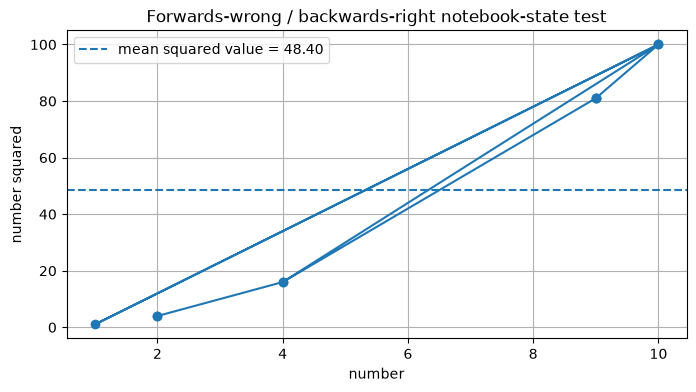

[DONE] Capture 000008: logged 4 artifact(s).


In [44]:
%%jupy_capture --label abc-second-pass-a
##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|44

In [45]:
## Code cell 28|45

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.t

<span style="font-size:80%;">Frustrating edit (orange) showing next to 
the cell is only due to the fact that I changed the second-time-around 
Code cell number.</span>

<details>
<summary>Click to see an example output from when this was 28</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
    + manifest.tsv
    + staging/
    + timelines/
</pre>

</details>

<br/><hr/>
<div>
<span style="font-size:150%; font-face:bold">MUST 
    MANUALLY PUT IN THE THE FILENAMES, BELOW!</span>
</div>
<div>Also make sure you have the 
    correct <code>first-pass</code> vs.
    the <code>second-pass</code> part
    of the filename.</div>

In [46]:
# Code cell 29|46

print("JUST BECAUSE THIS WAS GOOD FOR DEBUGGING, I'M")
print("GOING TO FIND ANYTHING FROM THE PREVIOUS TRY")
print("AND FROM THIS TRY THAT HAVE TO DO WITH CELL A.")

import contextlib
import io

import filecmp

buffer = io.StringIO()  # string streamer

with contextlib.redirect_stdout(buffer):
   dpypd.tree(f"{repo_root}/jupy_log")
##endof:  with contextlib.redirect_stdout(buffer)

tree_out_str = buffer.getvalue()

grep_a_cell_results = [
    line
    for line in tree_out_str.splitlines()
    if r"abc-" in line and r"pass-a-" in line
]

print(*grep_a_cell_results, sep="\n")
print()
print()
display_banner()
display_banner("=")
display_banner("#")
print()
display_banner("#")
display_banner("=")
display_banner()
print()

filename_1 = (
    repo_root / "jupy_log" / "artifacts" 
              / ("000010_1782760399754_2026-06-29T151319754-0400_"
                 "abc-first-pass-a-input.py")
)
filename_2 = (
    repo_root / "jupy_log" / "artifacts" 
              / ("000018_1782762473892_2026-06-29T154753892-0400_"
                 "abc-second-pass-a-input.py")
)
#              / ("000011_1782760400224_2026-06-29T151320224-0400_"
#                 "abc-first-pass-a-exception.txt")
#)

#  Set shallow=False to compare internal contents rather than 
#+ just file metadata
are_identical = filecmp.cmp(filename_1, filename_2, shallow=False)

correct_verbiage = (
    "  have contents that are identical."
    if are_identical
    else
    "  have contents that are not identical."
)

print(f"filename_1: '{filename_1}'\n  and\nfilename_2: '{filename_2}'\n{correct_verbiage}")

JUST BECAUSE THIS WAS GOOD FOR DEBUGGING, I'M
GOING TO FIND ANYTHING FROM THE PREVIOUS TRY
AND FROM THIS TRY THAT HAVE TO DO WITH CELL A.
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
        + 000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
        + 000019_1782762474682_2026-06-29T154754682-0400_abc-second-pass-a-stdout.txt
        + 000020_1782762474692_2026-06-29T154754692-0400_abc-second-pass-a-display-01-01-text.txt
        + 000021_1782762474700_2026-06-29T154754700-0400_abc-second-pass-a-display-01-02-image.png


-----------------------------------------------------------------
#################################################################

#################################################################
-----------------------------------------------------------------

filename_1: 'D:\David\my_repos_dwb\multimodal-jupy-logge

<details>
<summary>Click to see example outputs for the debug-type stuff</summary>
<br/>

**Quick debug-type results** from Code cell **29**|46

```text
JUST BECAUSE THIS WAS GOOD FOR DEBUGGING, I'M
GOING TO FIND ANYTHING FROM THE PREVIOUS TRY
AND FROM THIS TRY THAT HAVE TO DO WITH CELL A.
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt


-----------------------------------------------------------------
=================================================================
#################################################################

#################################################################
=================================================================
-----------------------------------------------------------------

filename_1: 'D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py'
  and
filename_2: 'D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt'
  have contents that are not identical.
```

<hr/>

**Quick debug-type results** from Code cell 29|**46**

```text
JUST BECAUSE THIS WAS GOOD FOR DEBUGGING, I'M
GOING TO FIND ANYTHING FROM THE PREVIOUS TRY
AND FROM THIS TRY THAT HAVE TO DO WITH CELL A.
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
        + 000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
        + 000019_1782762474682_2026-06-29T154754682-0400_abc-second-pass-a-stdout.txt
        + 000020_1782762474692_2026-06-29T154754692-0400_abc-second-pass-a-display-01-01-text.txt
        + 000021_1782762474700_2026-06-29T154754700-0400_abc-second-pass-a-display-01-02-image.png


-----------------------------------------------------------------
=================================================================
#################################################################

#################################################################
=================================================================
-----------------------------------------------------------------

filename_1: 'D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py'
  and
filename_2: 'D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py'
  have contents that are not identical.
```

<strong>But only different because I fixed the ordering of the Code cells.</strong>

</summary>

In [47]:
##  Code cell 30|47 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 21

000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000018
capture_sequence: 000008
role: input
label: abc-second-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"


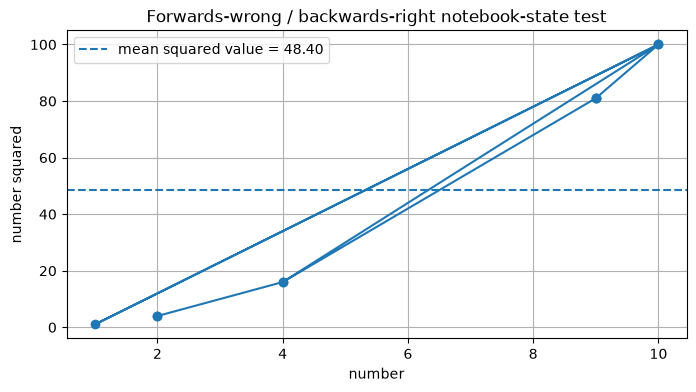

-----------------------------------------------------------------

About the binary image file... The file directly
above should let you know if it exists.
(Hint: not on the first pass.)

But the image will have shown up on the second pass.


########################################################################


In [48]:
##  Code cell 31|48, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(18) # was 10
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(19) # was 11
display_banner()
#begin only-second-time#
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(20)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(21)
display_banner()
#endof only-second-time*
print()
print("About the binary image file... The file directly")
print("above should let you know if it exists.")
print("(Hint: not on the first pass.)")
print()
print("But the image will have shown up on the second pass.")
print(); print()
display_banner("#", 72)

---

**New stuff after Code cell (30 &amp;) 31, 
later for (47 &amp;) 48**

_Those all relate to **Cell A**_


**` Cell A     .`**<br/>
**` First try  .`**

<details>
<summary>Click the arrow to see the file contents for 
    Code cells 30 &amp; 31.
    Both related to <strong>Cell A</strong>.
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/><hr/><br/>
**For Code cell 30 — Cell A related**
<br/>
**Manifest Stuff**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 11

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
-----------------------------------------------------------------
</pre>

<br/><hr/><br/>
**For code cell 31 — Cell A related**
<br/>
**Artifact Stuff** (Be sure to escape)

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000010
capture_sequence: 000004
role: input
label: abc-first-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|43

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000011
capture_sequence: 000004
role: exception
label: abc-first-pass-a-exception
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
exists: True

Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\IPython\core\interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bball\AppData\Local\Temp\ipykernel_13164\2702192110.py", line 7, in <module>
    avg_value = squared_numbers.mean()
                ^^^^^^^^^^^^^^^
NameError: name 'squared_numbers' is not defined

-----------------------------------------------------------------

About the binary image file... The file directly
above should let you know if it exists.
(Hint: not on the first pass.)

But the image will have shown up on the second pass.


########################################################################
</pre>

</details>

<br/><hr/><br/>

**` Cell A     .`**<br/>
**` Second try .`**

<details>
<summary>Click the arrow to see the file contents for 
    Code cell <strike>27|<strong>39+x</strong></strike>
    27|<strong>44</strong> &mdash; THE <strong>Cell
    A</strong> second attempt.
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

**Note for Cell A (second), Code cell ~~39+x~~ 44**

_These observations are for the first time I ran the cell
and will probably not match the plot in this notebook._ -DWB

<div style="background-color: cyan; max-width: 750px; width: fit-content;">
<span style="font-family: monospace;">
<strong><em>
That plot has a very interesting way of showing that one degenerate<br/>
(repeated) <strike>, degenerate might not be the right word, eh 
kamMA?)</strike> value is 64<br/>
in <code style="background-color: cyan;">squared_numbers</code>, seen 
in the plot on the x-axis as 8 
in <code style="background-color: cyan;">numbers</code>.<br/>
One can see that more than two lines <em>come in</em>/<em>go out</em> at
(8, 64).<br/>
(9, 81) is another repeated value pair. The reason we don&apos;t 
see<br/>
the extra visits is simple.
</em></strong>
</span>

<div style="background-color: white"><br></div>

<details>
<summary>
<span style="font-family: monospace;">
<strong><em>Click to see the reason, 
if nested details/summary tags are allowed.</em></strong>
</span>
</summary>

<div style="background-color: white;">They are allowed!</div>
    

<div style="background-color: #FF8B00;">
The <code style="background-color: #FF8B00;">numbers</code> array is 
represented 
as <code style="background-color: #FF8B00;"
       >[8  2  8  6  8  9  9  5  3  10]</code>.

First of all, 9 goes from itself to itself in a connected scatter plot
(not the best choice of visualization in this situation, we will have
 to discuss that, kamMA.) The scatter plot makes things interesting in
another way; If we trace traversals between numbers, we can see that
several paths are traversed mutliple times. Let's walk the whole...
graph-like thingie, then order each path from small number to big,
then group our edge-like thingies.

<code style="background-color: #FF8B00;"
    >(8 → 2, 2 → 8, 8 → 6, 6 → 8, 8 → 9, 9 → 9, 9 → 5, 5 → 3, 3 → 10)</code>

each directed segment (-ish) becomes an edge (-ish) when one goes
<code style="background-color: #FF8B00;"
    >smaller ↔ same-or-larger</code> in every case.

<code style="background-color: #FF8B00;"
    >(2 ↔ 8, 2 ↔ 8, 6 ↔ 8, 6 ↔ 8, 8 ↔ 9, 9 ↔ 9, 5 ↔ 9, 3 ↔ 5, 3 ↔ 10)</code>

Now, we can order and group these, comparing firsts, and if the firsts
are the same, comparing seconds.

<code style="background-color: #FF8B00;"
    >(
  2↔8, 2↔8,  # Edge traversed twice
  3↔5,
  3↔10,
  5↔9,
  6↔8, 6↔8,  # Edge traversed twice
  8↔9,
  9↔9
)</code>

So we have two edges traversed twice. What an unnecessary but
interesting tangent. I was just trying to figure out how I could
analyze the distribution.
</div>
</div>

</details>

<br/>

<span style="font-family: monospace; background-color: cyan;"
    ><strong><em>Cyan for fun!!!</em></strong></span>

</details>

<br/><hr/><br/>

<details>
<summary>Click the arrow to see the file contents for 
    Code cells <strike>39+x+3 &amp; 
    39+x+4.</strike> 47 &amp; 48.
    All related to <strong>Cell A</strong>.
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>
</summary>
    
**For Code cell ~~39+x+3~~ 47 — Cell A related** 
<br/>
**Manifest Stuff**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 21

000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
000014 | 000006 | input | text/x-python | abc-cell-c-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782761483982_2026-06-29T153123982-0400_abc-cell-c-input.py
000015 | 000006 | stdout | text/plain | abc-cell-c-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782761484600_2026-06-29T153124600-0400_abc-cell-c-stdout.txt
000016 | 000007 | input | text/x-python | abc-second-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782761684196_2026-06-29T153444196-0400_abc-second-pass-b-input.py
000017 | 000007 | stdout | text/plain | abc-second-pass-b-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1782761684212_2026-06-29T153444212-0400_abc-second-pass-b-stdout.txt
000018 | 000008 | input | text/x-python | abc-second-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
000019 | 000008 | stdout | text/plain | abc-second-pass-a-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000019_1782762474682_2026-06-29T154754682-0400_abc-second-pass-a-stdout.txt
000020 | 000008 | display | text/plain | abc-second-pass-a-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782762474692_2026-06-29T154754692-0400_abc-second-pass-a-display-01-01-text.txt
000021 | 000008 | display | image/png | abc-second-pass-a-display-01-02-image | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1782762474700_2026-06-29T154754700-0400_abc-second-pass-a-display-01-02-image.png
-----------------------------------------------------------------
</pre>

<br/><hr/><br/>
**For Code cell ~~39+x+4~~ 48 — Cell A related**
<br/>
**Artifact Stuff** (Be sure to escape)

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000018
capture_sequence: 000008
role: input
label: abc-second-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|44

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000019
capture_sequence: 000008
role: stdout
label: abc-second-pass-a-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000019_1782762474682_2026-06-29T154754682-0400_abc-second-pass-a-stdout.txt
exists: True

saved explicit plot file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png
explicit plot exists: True

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000020
capture_sequence: 000008
role: display
label: abc-second-pass-a-display-01-01-text
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782762474692_2026-06-29T154754692-0400_abc-second-pass-a-display-01-01-text.txt
exists: True

&lt;Figure size 800x400 with 1 Axes&gt;
-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000021
capture_sequence: 000008
role: display
label: abc-second-pass-a-display-01-02-image
mime: image/png
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1782762474700_2026-06-29T154754700-0400_abc-second-pass-a-display-01-02-image.png
exists: True


-----------------------------------------------------------------

About the binary image file... The file directly
above should let you know if it exists.
(Hint: not on the first pass.)

But the image will have shown up on the second pass.


########################################################################
</pre>

</details>

<hr/>

---

<span style="font-size: 150%; font-face: bold;">You 
can skip the next stuff (to the crossed out 
<code>h2</code>, the <strong>## 19</strong>,) where
your first code cell will be Code cell 48, 
<strong>if you've done B and A twice</strong>. 
Otherwise, keep going down with 
Cell B, which is Code cell 32.</span>

---

---

**If you have finished A, B, C, then back to B, A**

**It's time to go to Code cell 39+x+4+1=49**, a.k.a. 
Code cell Z, where $Z=49$ (because $x=5$) which is 
is after **\## 19**, the crossed out `h2`.

Links never seem to work. Scrolling time.

Unless you haven't done A twice, in which case you
can just go on to the next cell.

---

---

**`=============`**<br/>
**`Cell B, below`**<br/>
**`=============`**<br/>
- For **16**
  (`Code cell         32 — first execution: expected failure`).
  This output is for cells **below** this Markdown cell.

  - Expected result:

```text
NameError involving squared_numbers
```

  - The capture should still log:
    * the input
    * the exception
    * any output produced before the exception, if present
  - _All this output comes from Code cells **below** this Markdown cell._
  - ACTUAL OUTPUT:

```text
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[33], line 1
----> 1 squared_numbers = numbers ** 2
      2 
      3 print("squared_numbers:", squared_numbers)
      4 

NameError: name 'numbers' is not defined
[DONE] Capture 000005: logged 2 artifact(s).
[MMJL] %%jupy_capture captured an execution error.
```

  - (Output again)
    - This time, with exception text (in the Jupyter notebook,
      the text with a red background) bolded (immediately
      below.) The dots anchoring and aligning the right side 
      weren't part of original output, nor of any following 
      output in which they appear.

**`---------------------------------------------------------------------------            .`**<br/>
**`NameError                                 Traceback (most recent call last)            .`**<br/>
**`Cell In[33], line 1                                                                    .`**<br/>
**`----> 1 squared_numbers = numbers ** 2                                                 .`**<br/>
**`      2                                                                                .`**<br/>
**`      3 print("squared_numbers:", squared_numbers)                                     .`**<br/>
**`      4                                                                                .`**<br/>
**`                                                                                       .`**<br/>
**`NameError: name 'numbers' is not defined                                               .`**<br/>
`[DONE] Capture 000005: logged 2 artifact(s).                                           .`<br/>
**`[MMJL] %%jupy_capture captured an execution error.                                     .`**

  - Output of `dpypd.tree()`

```text
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
        + 000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
        + 000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
    + manifest.tsv
    + staging/
    + timelines/
```

  - All content of `manifest.tsv`

```text
artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
000001		1782759815228_2026-06-29T150335228-0400	text	text/markdown	literal	details-summary-markdown-regression	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002		1782759848405_2026-06-29T150408405-0400	html	text/html	literal	details-summary-html-control	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003	000001	1782760095550_2026-06-29T150815550-0400	text	text/x-python	input	capture-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004	000001	1782760095856_2026-06-29T150815856-0400	text	text/plain	stdout	capture-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005	000002	1782760174892_2026-06-29T150934892-0400	text	text/x-python	input	tee-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006	000002	1782760174910_2026-06-29T150934910-0400	text	text/plain	stdout	tee-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007	000002	1782760174921_2026-06-29T150934921-0400	text	text/plain	display	tee-basic-display-01-01-text	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
000008	000003	1782760280557_2026-06-29T151120557-0400	text	text/x-python	input	abc-state-reset-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
000009	000003	1782760280576_2026-06-29T151120576-0400	text	text/plain	stdout	abc-state-reset-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
000010	000004	1782760399754_2026-06-29T151319754-0400	text	text/x-python	input	abc-first-pass-a-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
000011	000004	1782760400224_2026-06-29T151320224-0400	text	text/plain	exception	abc-first-pass-a-exception	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
000012	000005	1782760985810_2026-06-29T152305810-0400	text	text/x-python	input	abc-first-pass-b-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
000013	000005	1782760985837_2026-06-29T152305837-0400	text	text/plain	exception	abc-first-pass-b-exception	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt

```

  - Content of `000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py` input text (code)

```python
squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

```

  - Content of `000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt` output text (exception)

```text
Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\IPython\core\interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bball\AppData\Local\Temp\ipykernel_13164\2522802886.py", line 1, in <module>
    squared_numbers = numbers ** 2
                      ^^^^^^^
NameError: name 'numbers' is not defined. Did you forget to import 'numbers'?

```

<br/>

Take note that the code file matches the code cell exactly,

<span style="font-size:175%">but, <strong>kamMA</strong>, just
as in the first, failed Cell A, the
exception text shown on the screen in the Jupyter
notebook <strong>does not</strong> match the text in the
exception logging file.</span>

<span style="font-size:125%">Interestingly, though the vital 
information matches, there is an interesting (but ultimately
unhelpful) hint that
appears in the logged exception versus the on-screen
exception. Once again, this section will probably be 
expanded with a _What I learned about Jupyter_ 
section.</span>

`---`

**What I learned about Jupyter from Cell B's failure**

---

**` Cell B     `**
**` Second try `**

- For **18** (`Code cell (still) 32 — second execution: expected success`)
- This would be code cell 32+y=40, (y=8) so I'm going to call it ~~**32|32+y**~~ **32|40**
  - The only difference in the input is the change,
    - from:
      - `%%jupy_capture --label abc-first-pass-b`
    - to:
      - `%%jupy_capture --label abc-second-pass-b`
  
  - ACTUAL OUTPUT
 
```text
squared_numbers: [  4   4  16 100   1 100  81  81  81  16]
[DONE] Capture 000007: logged 2 artifact(s).
```

The rest of the successful run's files' contents can be seen in the output of Code cells ~~**32+y+2** (with 34|**32+y+2**) and **32+y+3** (with 35|**32+y+3**)~~ **42** (with 34|**42**) and **43** (with 35|**43**)

In [40]:
%%jupy_capture --label abc-second-pass-b
squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

squared_numbers: [  4   4  16 100   1 100  81  81  81  16]
[DONE] Capture 000007: logged 2 artifact(s).


In [41]:
## Code cell 33|41

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.t

<details>
<summary>Click to see an example output from when it was cell 33</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
        + 000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
        + 000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
    + manifest.tsv
    + staging/
    + timelines/
</pre>

</details>

In [42]:
##  Code cell 34|42 — Manifest Check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 17

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 00000

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [43]:
##  Code cell 35|43, ANYTHING NEW?

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(12)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(13)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000012
capture_sequence: 000005
role: input
label: abc-first-pass-b-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
exists: True

squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000013
capture_sequence: 000005
role: exception
label: abc-first-pass-b-exception
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_17827609

---

**New stuff after Code cell (34 &amp; ) 35, later for (42 &amp;) 43**

_Those all relate to **Cell B**_

<details>

<summary>Click the arrow to see the file contents for 
    Code cells (35 &amp; 36) then <strike>( 32+y+2 &amp; 32+y+3
    )</strike>. 42 &amp; 43
    All related to <strong>Cell B</strong>.
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/><hr/><br/>
**For Code cell 34 — Cell B related**
<br/>
**Manifest Stuff**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 13

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
-----------------------------------------------------------------
</pre>

<br/><hr/><br/>
**For Code cell 35 — Cell B related**
<br/>
**Artifact Stuff**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000012
capture_sequence: 000005
role: input
label: abc-first-pass-b-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
exists: True

squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000013
capture_sequence: 000005
role: exception
label: abc-first-pass-b-exception
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
exists: True

Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\IPython\core\interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bball\AppData\Local\Temp\ipykernel_13164\2522802886.py", line 1, in &lt;module&gt;
    squared_numbers = numbers ** 2
                      ^^^^^^^
NameError: name 'numbers' is not defined. Did you forget to import 'numbers'?

-----------------------------------------------------------------


########################################################################
</pre>

<br/><hr/><br/>

**` Cell B     `**
**` Second try `**

**For Code cell ~~32+y+2~~ 42 — Cell B related**
<br/>
**Manifest Stuff**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 17

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
000014 | 000006 | input | text/x-python | abc-cell-c-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782761483982_2026-06-29T153123982-0400_abc-cell-c-input.py
000015 | 000006 | stdout | text/plain | abc-cell-c-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782761484600_2026-06-29T153124600-0400_abc-cell-c-stdout.txt
000016 | 000007 | input | text/x-python | abc-second-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782761684196_2026-06-29T153444196-0400_abc-second-pass-b-input.py
000017 | 000007 | stdout | text/plain | abc-second-pass-b-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1782761684212_2026-06-29T153444212-0400_abc-second-pass-b-stdout.txt
-----------------------------------------------------------------
</pre>

<br/><hr/><br/>
**For Code cell ~~32+y+3~~ 43 — Cell B related**

**Artifact Stuff**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000012
capture_sequence: 000005
role: input
label: abc-first-pass-b-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
exists: True

squared_numbers = numbers ** 2

print("squared_numbers:", squared_numbers)

## 16. Code cell         32 — B, first execution: expected failure
#
## and
#
## 18. Code cell (still) 32 — B, second execution: expected success
##     call it Code cell 32|40

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000013
capture_sequence: 000005
role: exception
label: abc-first-pass-b-exception
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
exists: True

Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\IPython\core\interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bball\AppData\Local\Temp\ipykernel_13164\2522802886.py", line 1, in <module>
    squared_numbers = numbers ** 2
                      ^^^^^^^
NameError: name 'numbers' is not defined. Did you forget to import 'numbers'?

-----------------------------------------------------------------


########################################################################
</pre>

</details>

<hr/>

---

<span style="font-size: 150%; font-face: bold;">If this has been your 
second time doing B, go back to A (Code cell 
27|<strong>44</strong>).</span>

And while you're having a look at Code cell (27|)**44**, don't 
forget to look at the Markdown above, which
details the change you make to the value handed the
<code>--label</code> option, and

<span style="font-size:150%">that change is to go from
the old<br/><code>--label abc-first-pass-a</code><br/>to the 
new<br/><code>--label abc-second-pass-a</code></span>,

Then, after finishing B and the following cells, you'll go
to A again (you'll be told where to go after finishing B.)

<span style="font-size:150%">If it is your first time doing 
the **Cell B** stuff, go ahead and continue down.</span>

---

**`=============`**<br/>
**`Cell C, below`**<br/>
**`=============`**<br/>
- For **17** (`Code cell 36 — C: expected success`)

  - Expected result:
    - Success. 
  - File contents for successful run
    - Look at the output of **Code cells 38-39**
  - ACTUAL OUTPUT

```text
numbers: [ 2  2  4 10  1 10  9  9  9  4]
[DONE] Capture 000006: logged 2 artifact(s).
```

In [36]:
%%jupy_capture --label abc-cell-c
import numpy as np
import matplotlib.pyplot as plt

## Older global-random-state style, like MLU
# numbers = np.random.randint(1, 11, size=10)

rng = np.random.default_rng()
numbers = rng.integers(1, 11, size=10)

print("numbers:", numbers)

## 17. Code cell 36 — C: expected success

numbers: [ 2  2  4 10  1 10  9  9  9  4]
[DONE] Capture 000006: logged 2 artifact(s).


<details>
<summary>Click to see an example output</summary>

<pre>
numbers: [ 2  2  4 10  1 10  9  9  9  4]
[DONE] Capture 000006: logged 2 artifact(s).
</pre>

</details>

In [37]:
## Code cell 37  # Skunks. I didn't change the f string. Too bad.

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\f{repo_root}\jupy_log


<details>
<summary>Click to see an example output</summary>

<pre>
# Messed it up this time; info in manifest.
</pre>

</details>

In [38]:
##  Code cell 38 — Manifest check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 15

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 00000

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

In [39]:
##  Code cell 39 — ANYTHING NEW?

display_banner("#", 72)
print()
display_banner()
show_artifact(14)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(15)
display_banner()
print(); print()
display_banner("#", 72)

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000014
capture_sequence: 000006
role: input
label: abc-cell-c-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782761483982_2026-06-29T153123982-0400_abc-cell-c-input.py
exists: True

import numpy as np
import matplotlib.pyplot as plt

## Older global-random-state style, like MLU
# numbers = np.random.randint(1, 11, size=10)

rng = np.random.default_rng()
numbers = rng.integers(1, 11, size=10)

print("numbers:", numbers)

## 17. Code cell 36 — C: expected success

-----------------------------------------------------------------

-----------------------------------------------------------------
artifact_sequence: 000015
capture_sequence: 000006
role: stdout
label: abc-cell-c-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1

---

**New stuff after Code cell 39**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

<br/><hr/><br/>
**For Code cell 38 (Manifest check) — Cell C related**

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 15

000001 |  | literal | text/markdown | details-summary-markdown-regression | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
000014 | 000006 | input | text/x-python | abc-cell-c-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782761483982_2026-06-29T153123982-0400_abc-cell-c-input.py
000015 | 000006 | stdout | text/plain | abc-cell-c-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782761484600_2026-06-29T153124600-0400_abc-cell-c-stdout.txt
-----------------------------------------------------------------
</pre>

<br/><hr/><br/>
**For Code cell 39 (Looking at artifacts) — Cell C related**

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000014
capture_sequence: 000006
role: input
label: abc-cell-c-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782761483982_2026-06-29T153123982-0400_abc-cell-c-input.py
exists: True

import numpy as np
import matplotlib.pyplot as plt

## Older global-random-state style, like MLU
# numbers = np.random.randint(1, 11, size=10)

rng = np.random.default_rng()
numbers = rng.integers(1, 11, size=10)

print("numbers:", numbers)

## 17. Code cell 36 — C: expected success

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000015
capture_sequence: 000006
role: stdout
label: abc-cell-c-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782761484600_2026-06-29T153124600-0400_abc-cell-c-stdout.txt
exists: True

numbers: [ 2  2  4 10  1 10  9  9  9  4]

-----------------------------------------------------------------


########################################################################
</pre>

</details>

---

<span style="font-size: 150%; font-face: bold;">If you 
haven't done B (and A) twice, go up and do B (Code cell 
32|<strong>40</strong>.)</span>

And while you're having a look at Code cell 32|**40**, 
don't forget to look at the Markdown above, which
details the change you make to the value handed the
<code>--label</code> option, and

<span style="font-size:150%">that change is to go from
the old<br/><code>--label abc-first-pass-b</code><br/>to the 
new<br/><code>--label abc-second-pass-b</code></span>,

Then, after finishing B and the following cells, you'll go
to A again (you'll be told where to go after finishing B.)

---

---

(**18** combined with **16** — both are Cell B) See above

---



## 19.~~Code cell~~ — ~~configure Matplotlib inline rendering~~ 

#### Note: trying (later: tried and succeeded) to do this earlier, in **13.1**

~~Run this before the successful A cell.~~

~~\`\`\``python`~~<br/>
~~`%matplotlib inline`~~<br/>
~~\`\`\`~~

---

---

(**20** combined with **16** — both are Cell A) See above

---

---

<span style="font-size: 150%; font-face: bold;">If you 
have done the whole A, B, C, then back for B and A, go ahead and
continue. Code cell Z will be your first to do, now. The last
one you should have completed was 39+x+4 (31|39+x+4)
but x=5, so the last one should have been 31|**48**, and 
39+x+4=Z-1, so we go to Code cell Z=49</span>

---

---

_For **15**&ndash;**20**, looking towards **21**_

This tests two related but distinct things:

* inline PNG capture by `%%jupy_capture`
* creation of a file that `%jupy_file` can log explicitly

In [49]:
## Code cell Z = 39+x+5 | _{x=5} => Code cell 49

dpypd.tree(f"{repo_root}/jupy_log")

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.t

<details>
<summary>Click to see an example output</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
        + 000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
        + 000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
        + 000014_1782761483982_2026-06-29T153123982-0400_abc-cell-c-input.py
        + 000015_1782761484600_2026-06-29T153124600-0400_abc-cell-c-stdout.txt
        + 000016_1782761684196_2026-06-29T153444196-0400_abc-second-pass-b-input.py
        + 000017_1782761684212_2026-06-29T153444212-0400_abc-second-pass-b-stdout.txt
        + 000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
        + 000019_1782762474682_2026-06-29T154754682-0400_abc-second-pass-a-stdout.txt
        + 000020_1782762474692_2026-06-29T154754692-0400_abc-second-pass-a-display-01-01-text.txt
        + 000021_1782762474700_2026-06-29T154754700-0400_abc-second-pass-a-display-01-02-image.png
    + manifest.tsv
    + staging/
        + abc_backwards_right.png
    + timelines/
</pre>

</details>

In [50]:
##  Code cell 50 — Manifest check

display_banner()
show_manifest(limit=20)
display_banner()

-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 21

000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-

<span style="font-size:150%; font-face:bold">MUST CHANGE (or at least
    check) <code>show_artifact</code> NUMBERS BELOW!</span>

########################################################################

-----------------------------------------------------------------
artifact_sequence: 000018
capture_sequence: 000008
role: input
label: abc-second-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"


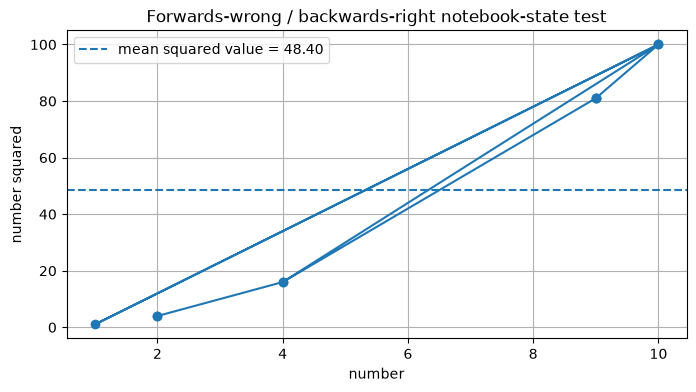

-----------------------------------------------------------------


########################################################################


In [51]:
##  Code cell 51, ~~ANYTHING NEW?~~ Nope, a review

########################################
##     REMEMBER TO MATCH NUMBERS!     ##
########################################

display_banner("#", 72)
print()
display_banner()
show_artifact(18)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(19)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(20)
display_banner()
display_banner("=", 70)
print()
display_banner("=", 70)
display_banner()
show_artifact(21)
display_banner()
print(); print()
display_banner("#", 72)

---

**~~New~~ Review stuff after Code cell 51**

<details>
<summary>Click the right-pointing triangle to see 
    the file contents. 
    Note that any internal HTML should be escaped,
    and downward-pointing triangles should come
    before expanded <code>&lt;detail&gt;</code>,
    <code>&lt;summary&gt;</code> pairs.</summary>

For the **manifest** (Code cell 50)

<pre>
-----------------------------------------------------------------
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
rows: 21

000002 |  | literal | text/html | details-summary-html-control | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
000003 | 000001 | input | text/x-python | capture-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
000004 | 000001 | stdout | text/plain | capture-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
000005 | 000002 | input | text/x-python | tee-basic-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
000006 | 000002 | stdout | text/plain | tee-basic-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
000007 | 000002 | display | text/plain | tee-basic-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
000008 | 000003 | input | text/x-python | abc-state-reset-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
000009 | 000003 | stdout | text/plain | abc-state-reset-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
000010 | 000004 | input | text/x-python | abc-first-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
000011 | 000004 | exception | text/plain | abc-first-pass-a-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
000012 | 000005 | input | text/x-python | abc-first-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
000013 | 000005 | exception | text/plain | abc-first-pass-b-exception | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
000014 | 000006 | input | text/x-python | abc-cell-c-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782761483982_2026-06-29T153123982-0400_abc-cell-c-input.py
000015 | 000006 | stdout | text/plain | abc-cell-c-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782761484600_2026-06-29T153124600-0400_abc-cell-c-stdout.txt
000016 | 000007 | input | text/x-python | abc-second-pass-b-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782761684196_2026-06-29T153444196-0400_abc-second-pass-b-input.py
000017 | 000007 | stdout | text/plain | abc-second-pass-b-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1782761684212_2026-06-29T153444212-0400_abc-second-pass-b-stdout.txt
000018 | 000008 | input | text/x-python | abc-second-pass-a-input | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
000019 | 000008 | stdout | text/plain | abc-second-pass-a-stdout | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000019_1782762474682_2026-06-29T154754682-0400_abc-second-pass-a-stdout.txt
000020 | 000008 | display | text/plain | abc-second-pass-a-display-01-01-text | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782762474692_2026-06-29T154754692-0400_abc-second-pass-a-display-01-01-text.txt
000021 | 000008 | display | image/png | abc-second-pass-a-display-01-02-image | D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1782762474700_2026-06-29T154754700-0400_abc-second-pass-a-display-01-02-image.png
-----------------------------------------------------------------
</pre>

---

For the **artifact(s)** (Code cell 51)

<pre>
########################################################################

-----------------------------------------------------------------
artifact_sequence: 000018
capture_sequence: 000008
role: input
label: abc-second-pass-a-input
mime: text/x-python
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
exists: True

##done before# import matplotlib.plotly as plt
##  P.S. Cell A does not import matplotlib here, because Cell C
##+ will do it before we come back for the successful run of
##+ already did. Same for numpy.
##+ This is intentional notebook-state dependence for the A/B/C test.

avg_value = squared_numbers.mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    numbers,
    squared_numbers,
    marker="o",
)

ax.axhline(
    avg_value,
    linestyle="--",
    label=f"mean squared value = {avg_value:.2f}",
)

ax.set_title(
    "Forwards-wrong / backwards-right notebook-state test"
)
ax.set_xlabel("number")
ax.set_ylabel("number squared")
ax.grid(True)
ax.legend()

plot_path = (
    repo_root
    / "jupy_log"
    / "staging"
    / "abc_backwards_right.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print("saved explicit plot file:", plot_path)
print("explicit plot exists:", plot_path.exists())

plt.show()

## 15. Code cell         27 — A, 1st execution: expected failure
#
## and
#
## 20. Code cell (still) 27 — A, 2nd execution: expected success and plot capture
##     call it Code Cell 27|44

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000019
capture_sequence: 000008
role: stdout
label: abc-second-pass-a-stdout
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000019_1782762474682_2026-06-29T154754682-0400_abc-second-pass-a-stdout.txt
exists: True

saved explicit plot file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging\abc_backwards_right.png
explicit plot exists: True

-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000020
capture_sequence: 000008
role: display
label: abc-second-pass-a-display-01-01-text
mime: text/plain
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782762474692_2026-06-29T154754692-0400_abc-second-pass-a-display-01-01-text.txt
exists: True

&lt;Figure size 800x400 with 1 Axes&gt;
-----------------------------------------------------------------
======================================================================

======================================================================
-----------------------------------------------------------------
artifact_sequence: 000021
capture_sequence: 000008
role: display
label: abc-second-pass-a-display-01-02-image
mime: image/png
path: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1782762474700_2026-06-29T154754700-0400_abc-second-pass-a-display-01-02-image.png
exists: True


-----------------------------------------------------------------


########################################################################
</pre>

</details>

<hr/>

---

For **21** (`Code cell 52 — test ``%jupy_file`` with the saved plot`)

The magic currently appends `-01` to the supplied label because it
supports logging multiple paths in one call.

In [52]:
get_ipython().run_line_magic(
    "jupy_file",
    (
        "--label abc-explicit-plot "
        "--mime image/png "
        f'"{plot_path}"'
    ),
)

## 21. Code cell 52 — test `%jupy_file` with the saved plot

[DONE] Logged image: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1782764942837_2026-06-29T162902837-0400_abc-explicit-plot-01.png


[WindowsPath('D:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/artifacts/000022_1782764942837_2026-06-29T162902837-0400_abc-explicit-plot-01.png')]

<details>
<summary>Click to see an example output</summary>

<pre>
[DONE] Logged image: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1782764942837_2026-06-29T162902837-0400_abc-explicit-plot-01.png
[WindowsPath('D:/David/my_repos_dwb/multimodal-jupy-logger/jupy_log/artifacts/000022_1782764942837_2026-06-29T162902837-0400_abc-explicit-plot-01.png')]
</pre>

</details>

---

~~Changed the return from `return out` to `return None` in `magics.py`:~~

```python
@line_magic
  def jupy_file(self, line: str = "")
```

<span style="font-size:200%;"><strong>kamMA</strong>, not really sure what to do about this one.</span>

In [53]:
## 22. Code cell 53 — initial manifest inspection and validation

%jupy_inspect

print("\n" + "-" * 72 + "\n")

%jupy_validate

Manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
Root: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
Artifacts: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts
Staging: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging
Timelines: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines
Rows: 22

By kind:
  html: 1
  image: 2
  text: 19

By MIME:
  image/png: 2
  text/html: 1
  text/markdown: 1
  text/plain: 10
  text/x-python: 8

------------------------------------------------------------------------

Manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
Rows checked: 22
Missing artifacts: 0


[]

<span style="font-size: 200%;"><strong>kamMA</strong>, something else 
    returned by a magic. An empty array in this case, but still 
    something.</span>

<details>
<summary>Click to see an example output</summary>

<pre>
Manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
Root: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
Artifacts: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts
Staging: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\staging
Timelines: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines
Rows: 22

By kind:
  html: 1
  image: 2
  text: 19

By MIME:
  image/png: 2
  text/html: 1
  text/markdown: 1
  text/plain: 10
  text/x-python: 8

------------------------------------------------------------------------

Manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
Rows checked: 22
Missing artifacts: 0
[]
</pre>

</details>

---

For **23** 
(`## Code cell `
~~Z+5~~ 
` 54 — instantiate a direct logger for programmatic inspection`)

This logger points at the same root as the registered magics.

In [54]:
## 23. Code cell 54 — instantiate a direct logger for programmatic inspection

log_root = repo_root / "jupy_log"
logger = MultimodalJupyLogger(root=log_root)

manifest_rows = logger.read_manifest_rows()

print("log_root:", log_root)
print("manifest:", logger.manifest)
print("artifact directory:", logger.artifacts)
print("manifest rows:", len(manifest_rows))

log_root: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
artifact directory: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts
manifest rows: 22


<details>
<summary>Click to see an example output</summary>

<pre>
log_root: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
artifact directory: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts
manifest rows: 22
</pre>

</details>

---

For **24** (`## Code cell `
~~Z+6~~ 
` 55 — inspect the most recent manifest rows`)

Look for groups corresponding to:

```text
details-summary-markdown-regression
details-summary-html-control
capture-basic
tee-basic
abc-state-reset
abc-first-pass-a
abc-first-pass-b
abc-cell-c
abc-second-pass-b
abc-second-pass-a
abc-explicit-plot
```

In [55]:
## 24. Code cell 55 — inspect the most recent manifest rows

catch_all_row_count = 30
all_rows = manifest_rows[-catch_all_row_count:]

for row in all_rows:
    print(
        row.get("artifact_sequence", ""),
        "capture=" + (row.get("capture_sequence", "") or "-"),
        "role=" + row.get("role", ""),
        "mime=" + row.get("mime", ""),
        "label=" + row.get("label", ""),
    )
##endof:  for row in recent_rows

000001 capture=- role=literal mime=text/markdown label=details-summary-markdown-regression
000002 capture=- role=literal mime=text/html label=details-summary-html-control
000003 capture=000001 role=input mime=text/x-python label=capture-basic-input
000004 capture=000001 role=stdout mime=text/plain label=capture-basic-stdout
000005 capture=000002 role=input mime=text/x-python label=tee-basic-input
000006 capture=000002 role=stdout mime=text/plain label=tee-basic-stdout
000007 capture=000002 role=display mime=text/plain label=tee-basic-display-01-01-text
000008 capture=000003 role=input mime=text/x-python label=abc-state-reset-input
000009 capture=000003 role=stdout mime=text/plain label=abc-state-reset-stdout
000010 capture=000004 role=input mime=text/x-python label=abc-first-pass-a-input
000011 capture=000004 role=exception mime=text/plain label=abc-first-pass-a-exception
000012 capture=000005 role=input mime=text/x-python label=abc-first-pass-b-input
000013 capture=000005 role=excepti

<details>
<summary>Click to see an example output</summary>

<pre>
000001 capture=- role=literal mime=text/markdown label=details-summary-markdown-regression
000002 capture=- role=literal mime=text/html label=details-summary-html-control
000003 capture=000001 role=input mime=text/x-python label=capture-basic-input
000004 capture=000001 role=stdout mime=text/plain label=capture-basic-stdout
000005 capture=000002 role=input mime=text/x-python label=tee-basic-input
000006 capture=000002 role=stdout mime=text/plain label=tee-basic-stdout
000007 capture=000002 role=display mime=text/plain label=tee-basic-display-01-01-text
000008 capture=000003 role=input mime=text/x-python label=abc-state-reset-input
000009 capture=000003 role=stdout mime=text/plain label=abc-state-reset-stdout
000010 capture=000004 role=input mime=text/x-python label=abc-first-pass-a-input
000011 capture=000004 role=exception mime=text/plain label=abc-first-pass-a-exception
000012 capture=000005 role=input mime=text/x-python label=abc-first-pass-b-input
000013 capture=000005 role=exception mime=text/plain label=abc-first-pass-b-exception
000014 capture=000006 role=input mime=text/x-python label=abc-cell-c-input
000015 capture=000006 role=stdout mime=text/plain label=abc-cell-c-stdout
000016 capture=000007 role=input mime=text/x-python label=abc-second-pass-b-input
000017 capture=000007 role=stdout mime=text/plain label=abc-second-pass-b-stdout
000018 capture=000008 role=input mime=text/x-python label=abc-second-pass-a-input
000019 capture=000008 role=stdout mime=text/plain label=abc-second-pass-a-stdout
000020 capture=000008 role=display mime=text/plain label=abc-second-pass-a-display-01-01-text
000021 capture=000008 role=display mime=image/png label=abc-second-pass-a-display-01-02-image
000022 capture=- role=file mime=image/png label=abc-explicit-plot-01
</pre>

</details>

In [56]:
## 25. Code cell 56 — inspect the log tree with `dpypd.tree`

dpypd.tree(
    this_dir=log_root,
    dirs_to_exclude=[
        "__pycache__",
    ],
    files_to_exclude=[
        ".pyc",
    ],
)

+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.t

<details>
<summary>Click to see an example output</summary>

<pre>
+ D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log
    + artifacts/
        + 000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
        + 000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
        + 000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
        + 000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
        + 000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
        + 000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
        + 000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
        + 000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
        + 000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
        + 000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
        + 000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
        + 000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
        + 000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
        + 000014_1782761483982_2026-06-29T153123982-0400_abc-cell-c-input.py
        + 000015_1782761484600_2026-06-29T153124600-0400_abc-cell-c-stdout.txt
        + 000016_1782761684196_2026-06-29T153444196-0400_abc-second-pass-b-input.py
        + 000017_1782761684212_2026-06-29T153444212-0400_abc-second-pass-b-stdout.txt
        + 000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
        + 000019_1782762474682_2026-06-29T154754682-0400_abc-second-pass-a-stdout.txt
        + 000020_1782762474692_2026-06-29T154754692-0400_abc-second-pass-a-display-01-01-text.txt
        + 000021_1782762474700_2026-06-29T154754700-0400_abc-second-pass-a-display-01-02-image.png
        + 000022_1782764942837_2026-06-29T162902837-0400_abc-explicit-plot-01.png
    + manifest.tsv
    + staging/
        + abc_backwards_right.png
    + timelines/
</pre>

</details>

In [57]:
## 26. Code cell 57 — use the `wc -l` analog

manifest_line_count = dpypd.count_lines(
    logger.manifest,
    do_print=True,
)

print(
    "Expected manifest data rows:",
    manifest_line_count - 1,
)
print(
    "Rows returned by read_manifest_rows:",
    len(manifest_rows),
)
print(
    "Counts agree:",
    manifest_line_count - 1 == len(manifest_rows),
)

D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv has 23 line(s)
Expected manifest data rows: 22
Rows returned by read_manifest_rows: 22
Counts agree: True


<details>
<summary>Click to see an example output</summary>

<pre>
D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv has 23 line(s)
Expected manifest data rows: 22
Rows returned by read_manifest_rows: 22
Counts agree: True
</pre>

</details>

---

For **27** (`Code cell `
~~Z+9~~
` 58 — use the ``cat`` analog on the manifest`)

Verify visually that:

* `artifact_sequence` increases monotonically
* capture artifacts share a `capture_sequence`
* the first failed A and B have exception rows
* the later B and A have successful output rows
* filenames contain both the sequence and epoch milliseconds

In [58]:
## Code cell 58 — use the `cat` analog on the manifest

dpypd.print_file(
    logger.manifest,
    show_line_numbers=True,
)

    1: artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
    2: 000001		1782759815228_2026-06-29T150335228-0400	text	text/markdown	literal	details-summary-markdown-regression	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
    3: 000002		1782759848405_2026-06-29T150408405-0400	html	text/html	literal	details-summary-html-control	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
    4: 000003	000001	1782760095550_2026-06-29T150815550-0400	text	text/x-python	input	capture-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
    5: 000004	000001	1782760095856_2026-06-29T150815856-0400	text	text/plain	stdout	capture-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\art

<details>
<summary>Click to see an example output</summary>

<pre>
    1: artifact_sequence	capture_sequence	timestamp	kind	mime	role	label	path
    2: 000001		1782759815228_2026-06-29T150335228-0400	text	text/markdown	literal	details-summary-markdown-regression	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000001_1782759815228_2026-06-29T150335228-0400_details-summary-markdown-regression.md
    3: 000002		1782759848405_2026-06-29T150408405-0400	html	text/html	literal	details-summary-html-control	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000002_1782759848405_2026-06-29T150408405-0400_details-summary-html-control.html
    4: 000003	000001	1782760095550_2026-06-29T150815550-0400	text	text/x-python	input	capture-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000003_1782760095550_2026-06-29T150815550-0400_capture-basic-input.py
    5: 000004	000001	1782760095856_2026-06-29T150815856-0400	text	text/plain	stdout	capture-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000004_1782760095856_2026-06-29T150815856-0400_capture-basic-stdout.txt
    6: 000005	000002	1782760174892_2026-06-29T150934892-0400	text	text/x-python	input	tee-basic-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000005_1782760174892_2026-06-29T150934892-0400_tee-basic-input.py
    7: 000006	000002	1782760174910_2026-06-29T150934910-0400	text	text/plain	stdout	tee-basic-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000006_1782760174910_2026-06-29T150934910-0400_tee-basic-stdout.txt
    8: 000007	000002	1782760174921_2026-06-29T150934921-0400	text	text/plain	display	tee-basic-display-01-01-text	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000007_1782760174921_2026-06-29T150934921-0400_tee-basic-display-01-01-text.txt
    9: 000008	000003	1782760280557_2026-06-29T151120557-0400	text	text/x-python	input	abc-state-reset-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000008_1782760280557_2026-06-29T151120557-0400_abc-state-reset-input.py
   10: 000009	000003	1782760280576_2026-06-29T151120576-0400	text	text/plain	stdout	abc-state-reset-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000009_1782760280576_2026-06-29T151120576-0400_abc-state-reset-stdout.txt
   11: 000010	000004	1782760399754_2026-06-29T151319754-0400	text	text/x-python	input	abc-first-pass-a-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000010_1782760399754_2026-06-29T151319754-0400_abc-first-pass-a-input.py
   12: 000011	000004	1782760400224_2026-06-29T151320224-0400	text	text/plain	exception	abc-first-pass-a-exception	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000011_1782760400224_2026-06-29T151320224-0400_abc-first-pass-a-exception.txt
   13: 000012	000005	1782760985810_2026-06-29T152305810-0400	text	text/x-python	input	abc-first-pass-b-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000012_1782760985810_2026-06-29T152305810-0400_abc-first-pass-b-input.py
   14: 000013	000005	1782760985837_2026-06-29T152305837-0400	text	text/plain	exception	abc-first-pass-b-exception	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000013_1782760985837_2026-06-29T152305837-0400_abc-first-pass-b-exception.txt
   15: 000014	000006	1782761483982_2026-06-29T153123982-0400	text	text/x-python	input	abc-cell-c-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000014_1782761483982_2026-06-29T153123982-0400_abc-cell-c-input.py
   16: 000015	000006	1782761484600_2026-06-29T153124600-0400	text	text/plain	stdout	abc-cell-c-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000015_1782761484600_2026-06-29T153124600-0400_abc-cell-c-stdout.txt
   17: 000016	000007	1782761684196_2026-06-29T153444196-0400	text	text/x-python	input	abc-second-pass-b-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000016_1782761684196_2026-06-29T153444196-0400_abc-second-pass-b-input.py
   18: 000017	000007	1782761684212_2026-06-29T153444212-0400	text	text/plain	stdout	abc-second-pass-b-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000017_1782761684212_2026-06-29T153444212-0400_abc-second-pass-b-stdout.txt
   19: 000018	000008	1782762473892_2026-06-29T154753892-0400	text	text/x-python	input	abc-second-pass-a-input	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000018_1782762473892_2026-06-29T154753892-0400_abc-second-pass-a-input.py
   20: 000019	000008	1782762474682_2026-06-29T154754682-0400	text	text/plain	stdout	abc-second-pass-a-stdout	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000019_1782762474682_2026-06-29T154754682-0400_abc-second-pass-a-stdout.txt
   21: 000020	000008	1782762474692_2026-06-29T154754692-0400	text	text/plain	display	abc-second-pass-a-display-01-01-text	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000020_1782762474692_2026-06-29T154754692-0400_abc-second-pass-a-display-01-01-text.txt
   22: 000021	000008	1782762474700_2026-06-29T154754700-0400	image	image/png	display	abc-second-pass-a-display-01-02-image	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000021_1782762474700_2026-06-29T154754700-0400_abc-second-pass-a-display-01-02-image.png
   23: 000022		1782764942837_2026-06-29T162902837-0400	image	image/png	file	abc-explicit-plot-01	D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\artifacts\000022_1782764942837_2026-06-29T162902837-0400_abc-explicit-plot-01.png
</pre>

</details>

---

For **28** (`Code cell `
~~Z+10~~
59` — generate both timelines`)

The equivalent magic calls are:

```python
%jupy_markdown
%jupy_html
```

Using the direct logger here makes the returned paths easy to retain.

In [59]:
## 28. Code cell 59 — generate both timelines

markdown_timeline_path = logger.build_markdown()
html_timeline_path = logger.build_html()

print("Markdown timeline:", markdown_timeline_path)
print("HTML timeline:", html_timeline_path)

[DONE] Markdown timeline written: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md
[DONE] HTML timeline written: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html
Markdown timeline: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md
HTML timeline: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html


<details>
<summary>Click to see an example output</summary>

<pre>
[DONE] Markdown timeline written: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md
[DONE] HTML timeline written: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html
Markdown timeline: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md
HTML timeline: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html
</pre>

</details>

In [60]:
## 29. Code cell 60 — count timeline lines

n_markdown_lines = dpypd.count_lines(
    markdown_timeline_path,
    do_print=True,
)

n_html_lines = dpypd.count_lines(
    html_timeline_path,
    do_print=True,
)

D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md has 450 line(s)
D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html has 329 line(s)


<details>
<summary>Click to see an example output</summary>

<pre>
D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md has 450 line(s)
D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html has 329 line(s)
</pre>

</details>

---

For **30** (`Code cell `
~~Z+12~~
` 61 — print the Markdown timeline`)

Things to check:

* artifact and capture sequences appear
* roles appear
* failed A and B occur before successful C, B, and A
* Python input is preserved
* exception text is preserved
* image links are present
* the Markdown `<details>` regression item is probably fenced rather than rendered

---

---

---

<span style="font-size: 350%; font-face: bold;">BIG PRINT MARKDOWN</span>

---

In [61]:
## 30. Code cell 61 — print the Markdown timeline

dpypd.print_file(
    markdown_timeline_path,
    show_line_numbers=False,
)

# Jupyter Log Timeline

**Multimodal Jupy Logger Markdown Timeline**

This log file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.md
Timestamp: 1782766002578_2026-06-29T164642578-0400
Machine, user, etc.: BLACK-MACHINE bball@BLACK-MACHINE

---

---

---


---

## details-summary-markdown-regression

`1782759815228_2026-06-29T150335228-0400` — `text` — `text/markdown`

```
<details>
<summary>Click the arrow to reveal logged Markdown text</summary>

This content was logged as `text/markdown`.

The regression question is whether exported timelines preserve this as
renderable Markdown/HTML or incorrectly turn it into escaped or fenced
source text.

</details>

<!-- ## 9. Code cell 08 — log the original Markdown regression case -->
<!--   If I had left the python comment without the HTML comment,   -->
<!-- + it would have rendered as an `h2`. But you might only see    -->
<!-- + this in the dpypd.print_file version.                        -->

<br/>HTML comments

---

---

<span style="font-size: 500%; font-face: bold;">REALLY BIG PRINT HTML</span>

---

For **31** (`Code cell `
~~Z+13~~
` 62 — inspect the raw HTML timeline source`)

This may be lengthy, but it is useful for this first pass.

Search visually for:

```text
details-summary-markdown-regression
details-summary-html-control
abc-first-pass-a
abc-first-pass-b
abc-second-pass-a
image/png
```

In [62]:
## 31. Code cell 62 — inspect the raw HTML timeline source

dpypd.print_file(
    html_timeline_path,
    show_line_numbers=True,
)

    1: <html>
    2: <body>
    3: <h1>Jupyter Log Timeline</h1>
    4: <pre>
    5: **Multimodal Jupy Logger HTML Timeline**
    6: 
    7: This log file: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\timelines\timeline.html
    8: Timestamp: 1782766002605_2026-06-29T164642605-0400
    9: Machine, user, etc.: BLACK-MACHINE bball@BLACK-MACHINE
   10: 
   11: ---
   12: 
   13: ---
   14: 
   15: ---
   16: 
   17: </pre>
   18: <hr>
   19: <h3>details-summary-markdown-regression</h3>
   20: <p><code>1782759815228_2026-06-29T150335228-0400</code> — text — text/markdown</p>
   21: <pre>&lt;details&gt;
   22: &lt;summary&gt;Click the arrow to reveal logged Markdown text&lt;/summary&gt;
   23: 
   24: This content was logged as `text/markdown`.
   25: 
   26: The regression question is whether exported timelines preserve this as
   27: renderable Markdown/HTML or incorrectly turn it into escaped or fenced
   28: source text.
   29: 
   30: &lt;/details&gt;
   31: 
   32: &lt;!-- ##

---

<span style="font-size: 150%; font-face: bold;">That was the raw HTML code.</span>

---

---

For **32** (`Code cell `
~~Z+14~~
` 63 — render the generated HTML timeline in the notebook`)

Regression expectations:

* the `text/html` control should show a clickable `<details>` arrow
* the `text/markdown` version may show escaped `<details>` source
* the successful A plot should appear if its captured `image/png` path is
  usable from the generated timeline
* exception entries should be visible in chronological artifact order

---

<span style="font-size: 350%; font-face: bold;">HERE COMES THE RENDERED HTML</span>

---

In [63]:
## 32. Code cell 63 — render the generated HTML timeline in the notebook

from IPython.display import HTML, display

display(
    HTML(
        filename=str(html_timeline_path),
    )
)

No image display due to the way Jupyter's server can get and show path stuff.

<span style="font-size:200%;">That was a good amount of HTML!</span>

In [64]:
## 33. Code cell 64 — final validation after exports

missing_paths = logger.validate_manifest()

print("\nFinal status:")
print("  manifest rows:", len(logger.read_manifest_rows()))
print("  missing artifact paths:", len(missing_paths))
print("  Markdown timeline exists:", markdown_timeline_path.exists())
print("  HTML timeline exists:", html_timeline_path.exists())
print("  explicit plot source exists:", plot_path.exists())

Manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
Rows checked: 22
Missing artifacts: 0

Final status:
  manifest rows: 22
  missing artifact paths: 0
  Markdown timeline exists: True
  HTML timeline exists: True
  explicit plot source exists: True


<details>
<summary>Click to see an example output</summary>

<pre>
Manifest: D:\David\my_repos_dwb\multimodal-jupy-logger\jupy_log\manifest.tsv
Rows checked: 22
Missing artifacts: 0

Final status:
  manifest rows: 22
  missing artifact paths: 0
  Markdown timeline exists: True
  HTML timeline exists: True
  explicit plot source exists: True
</pre>

</details>

In [65]:
## 34. Code cell 65 — final ordering assertions

final_rows = logger.read_manifest_rows()

artifact_sequences = [
    int(row["artifact_sequence"])
    for row in final_rows
]

sequences_are_monotonic = (
    artifact_sequences
    == sorted(artifact_sequences)
)

sequences_are_unique = (
    len(artifact_sequences)
    == len(set(artifact_sequences))
)

filenames_have_sequence_prefixes = all(
    pathlib.Path(row["path"]).name.startswith(
        f"{int(row['artifact_sequence']):06d}_"
    )
    for row in final_rows
)

print("Artifact sequences monotonic:", sequences_are_monotonic)
print("Artifact sequences unique:", sequences_are_unique)
print(
    "Filenames begin with artifact sequence:",
    filenames_have_sequence_prefixes,
)

Artifact sequences monotonic: True
Artifact sequences unique: True
Filenames begin with artifact sequence: True


<details>
<summary>Click to see an example output</summary>

<pre>
Artifact sequences monotonic: True
Artifact sequences unique: True
Filenames begin with artifact sequence: True
</pre>

</details>

## 35. Markdown cell — record the result

### Test-result notes

Record the observations here:

- [x] repository-root discovery worked
- [x] imports worked
- [x] utility module alias worked
- [x] individual utility imports worked
- [x] magics registered
- [x] notebook-native `<details>` worked
- [x] `text/markdown` regression behavior observed
- [x] `text/html` control rendered
- [x] `%%jupy_capture` executed and logged
- [x] `%%jupy_tee` executed and logged
- [x] first A failed as expected
- [x] first B failed as expected
- [x] C succeeded
- [x] second B succeeded
- [x] second A succeeded
- [x] inline Matplotlib plot was captured
- [x] explicit `%jupy_file` plot was logged
- [x] manifest sequences were monotonic
- [x] capture groups were visible
- [x] filenames contained millisecond timestamps
- [x] validation reported no missing artifacts
- [x] Markdown timeline was generated
- [x] HTML timeline was generated
- [x] timeline execution history was reconstructable

In [66]:
%history

## 2. Code cell 01 — locate the repository root and configure `sys.path`
import importlib
import os
import sys
import pathlib

starting_dir = pathlib.Path.cwd().resolve()
repo_root = None
src_path = None
package_path = None

for candidate_path in [starting_dir, *starting_dir.parents]:
    package_path = (
        candidate_path
        / "src"
        / "multimodal_jupy_logger"
    )

    if package_path.is_dir():
        repo_root = candidate_path
        break
    ##endof:  if package_path.is_dir()
##endof:  for candidate_path in [...]

if repo_root is None:
    raise RuntimeError(
        "Could not find a repository root containing "
        "src/multimodal_jupy_logger."
    )
##endof:  if repo_root is None

src_path = repo_root / "src"

os.chdir(repo_root)

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
##endof:  if str(src_path) not in sys.path

importlib.invalidate_caches()

print("starting_dir:", starting_dir)
print("repo_root:", repo_root)
print("src_p

In [71]:
import multimodal_jupy_logger.jupy_pdf_utils

multimodal_jupy_logger.jupy_pdf_utils.register_pdf_magics()

[DONE] Registered: %backup_pdf from the file,
         src/multimodal_jupy_logger/jupy_pdf_utils.py


True

In [73]:
%backup_pdf

Triggering notebook save via frontend JavaScript...


<IPython.core.display.Javascript object>

Generating optimized layout PDF for mmjl_capture_debugging_pre.ipynb...


Task exception was never retrieved
future: <Task finished name='Task-346' coro=<Connection.run() done, defined at D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\playwright\_impl\_connection.py:305> exception=NotImplementedError()>
Traceback (most recent call last):
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\playwright\_impl\_connection.py", line 312, in run
    await self._transport.connect()
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\playwright\_impl\_transport.py", line 133, in connect
    raise exc
  File "D:\David\my_repos_dwb\multimodal-jupy-logger\.venv_mmjl_test\Lib\site-packages\playwright\_impl\_transport.py", line 120, in connect
    self._proc = await asyncio.create_subprocess_exec(
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<9 lines>...
    )
    ^
  File "C:\Users\bball\AppData\Local\Programs\Python\Python313\Lib\asyncio\subprocess.py",

NotImplementedError: 